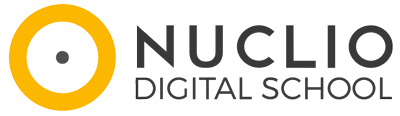


# **Modulo 4. Análisis de datos - Proyecto final**



# **Caso práctico**
***Análisis de mercado para la apertura de centros especializados de Halterofilia***

***Lift & Lead***, es una startup interesada en abrir centros de entrenamiento especializados en halterofilia ya que con el auge del CrossFit, que integra técnicas de halterofilia, los fundadores creen que este puede ser un buen momento para invertir en centros dedicados exclusivamente a este deporte.

La dirección de ***Lift & Lead*** busca validar la hipótesis de que la popularidad del CrossFit está impulsando el interés por la halterofilia en Europa.

Actualmente no cuentan con mucho conocimiento y para empezar a comprender mejor el sector de la halterofilia y a sus atletas, te han asignado la tarea de analizar los resultados de los campeonatos europeos de halterofilia.

El análisis se hará en dos fases:

1. **Fase 1**: Te han proporcionado acceso a la base de datos de 2019 y 2020
  - La información fue obtenida a través de los siguientes enlaces por el anterior Data Analyst que ha dejado la compañía:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2019
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2020

2. **Fase 2:** Quieren enriquecer el análisis consideranto un periodo más amplio, incluyendo desde 2019 a 2024 pero no disponen de la información. Para obtenerla harás uso de web scraping de los siguientes enlaces:
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2021
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023
    - https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024


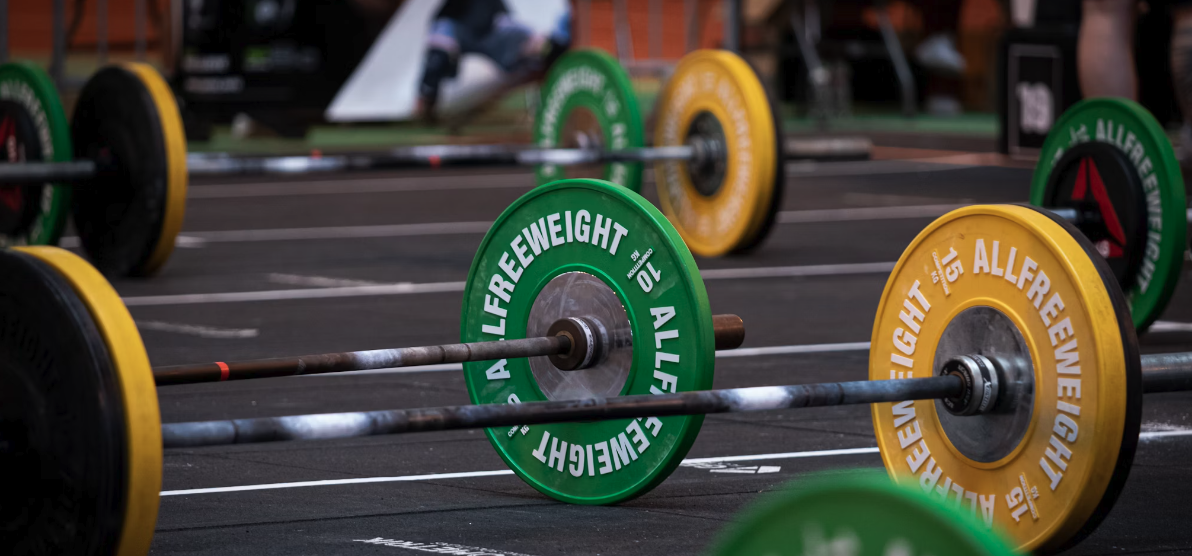

# **Parte 1.** Disponemos de la información

## Paso 1. Importar librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from fuzzywuzzy import process

import os
import re

import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import requests

c:\Users\Usuario\anaconda3\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## Paso 2. Cargar datos

In [2]:
def cargar_datos(fichero):
   try:
      if 'csv' in fichero:
         df = pd.read_csv(fichero)
      else:
         df = pd.read_excel(fichero)
      return df
   except Exception as e:
     print(f'Error: {e}')

In [3]:
# Ruta relativa a la carpeta data/ del repositorio
path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data')

lista_ficheros = os.listdir(path)

lista_ficheros_proyecto = [fichero for fichero in lista_ficheros if 'Campeonato' in fichero]
lista_ficheros_proyecto

['Campeonato Europeo de Halterofilia de 2019 datos original.csv',
 'Campeonato Europeo de Halterofilia de 2020 datos original.csv']

In [4]:
dict_datos = {}

for fichero in lista_ficheros_proyecto:
    print(fichero)
    path_file = os.path.join(path, fichero)
    df = cargar_datos(path_file)
    
    if '2019' in fichero:
        nombre_clave = '2019'
    elif '2020' in fichero:
        nombre_clave = '2020'
    
    dict_datos[nombre_clave] = df

dict_datos.keys()

Campeonato Europeo de Halterofilia de 2019 datos original.csv
Campeonato Europeo de Halterofilia de 2020 datos original.csv


dict_keys(['2019', '2020'])

## Paso 3. Exploración inicial

In [5]:
def exploracion_inicial(df):
    """
    Realiza una exploración inicial de un DataFrame y muestra información clave.

    Parámetros:
    df (pd.DataFrame): El DataFrame a explorar.
    tipo (str, opcional): El tipo de exploración. 'simple' muestra menos detalles.

    Imprime:
    Información relevante sobre el DataFrame, incluyendo filas, columnas, tipos de datos,
    estadísticas descriptivas, y valores nulos.
    """

    # Información básica sobre el DataFrame
    num_filas, num_columnas = df.shape
    print(f"¿Cuántas filas y columnas hay en el conjunto de datos?")
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    # Exploración completa
    print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
    display(df.head())
    print('-' * 100)

    print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
    display(df.tail())
    print('-' * 100)

    print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
    display(df.sample(n=5))
    print('-' * 100)

    print("¿Cuáles son las columnas del conjunto de datos?")
    print("\n".join(f"\t- {col}" for col in df.columns))
    print('-' * 100)

    print("¿Cuál es el tipo de datos de cada columna?")
    print(df.dtypes)
    print('-' * 100)

    print("¿Cuántas columnas hay de cada tipo de datos?")
    print(df.dtypes.value_counts())
    print('-' * 100)

    print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
    print(df.info())
    print('-' * 100)

    print("¿Cuántos valores únicos tiene cada columna?")
    print(df.nunique())
    print('-' * 100)

    print("¿Cuáles son los valores únicos de cada columna?")
    df_valores_unicos = pd.DataFrame(df.apply(lambda x: x.unique()))
    display(df_valores_unicos)
    print('-' * 100)

    print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
    display(df.describe(include='all').fillna(''))
    print('-' * 100)

    print("¿Cuántos valores nulos hay en cada columna del DataFrame?")
    display(df.isnull().sum())
    print('-' * 100)

    print("¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?")
    df_nulos = df.isnull().sum().div(len(df)).mul(100).round(2).reset_index().rename(columns = {'index': 'Col', 0: 'pct'})
    df_nulos = df_nulos.sort_values(by = 'pct', ascending=False).reset_index(drop = True)
    display(df_nulos)
    print('-' * 100)

    print("## Valores nulos: Visualización")
    msno.bar(df, figsize = (6, 3), fontsize= 9)
    plt.show()
    print('-' * 100)


    print("## Visualización de patrones en valores nulos")
    msno.matrix(df, figsize = (6, 3), fontsize= 9, sparkline = False)
    plt.show()
    print('-' * 100)

    '''
    msno.heatmap(df, figsize = (6, 3), fontsize= 9)
    plt.show()
    print('-' * 100)
    '''

print('#' * 90)

##########################################################################################


################################ 2019 ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 20 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​,2019,Masculino
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282,2019,Masculino
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculino
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335,2019,Masculino
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354,2019,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
15,71 kg (10.04),Anastasiya Romanova Rusia 112 + 128 = 240,Emily Godley Reino Unido 93 + 123 = 216,Mădălina Molie Rumania 101 + 114 = 215,2019,Femenino
16,76 kg (11.04),Daria Naumava Bielorrusia 106 + 136 = 242,Lidia Valentín[2]​ España 108 + 133 = 241,Patricia Strenius Suecia 101 + 132 = 233,2019,Femenino
17,81 kg[n 2]​ (12.04),Nina Schroth Alemania 102 + 120 = 222,Anna Van Bellinghen Bélgica 103 + 118 = 221,Liana Guiurdzhian Armenia 97 + 120 = 217,2019,Femenino
18,87 kg (12.04),Xeniya Pasjina Rusia 110 + 132 = 242,Diana Mstiyeva Rusia 110 + 130 = 240,Sarah Fischer Austria 102 + 129 = 231,2019,Femenino
19,+87 kg (13.04),Tatiana Kashirina Rusia 146 + 185 = 331,Anastasiya Lysenko Ucrania 120 + 148 = 268,Emily Campbell Reino Unido 115 + 145 = 260,2019,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


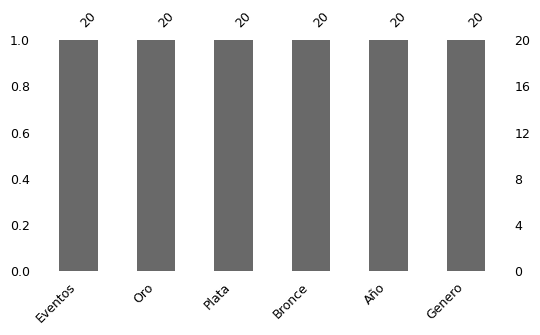

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


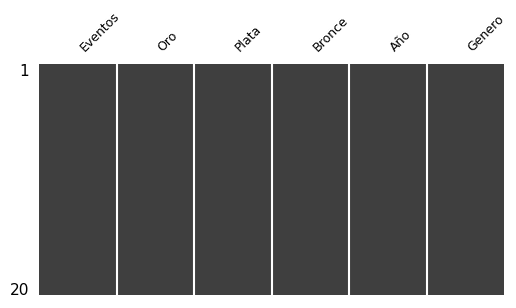

----------------------------------------------------------------------------------------------------
################################ 2020 ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 20 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Rumania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ucrania 110 + 137 = 247[n 1]​,2020,Masculino
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turquía 130 + 157 = 287,2020,Masculino
2,67 kg (05.04),Muhammed Özbek Turquía 145 + 178 = 323,Mirko Zanni Italia 148 + 170 = 318,Valentin Guenchev Bulgaria 138 + 177 = 315,2020,Masculino
3,73 kg (06.04),Daniyar İsmayilov Turquía 160 + 181 = 341,Marin Robu Moldavia 156 + 183 = 339,Briken Calja Albania 152 + 184 = 336,2020,Masculino
4,81 kg (07.04),Antonino Pizzolato Italia 164 + 206 = 370,Karlos Nasar Bulgaria 163 + 206 = 369,Ritvars Suharevs Letonia 157 + 190 = 347,2020,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
15,71 kg (07.04),Emily Godley Reino Unido 98 + 129 = 227,Alessia Durante Italia 97 + 122 = 219,Raluca Olaru Rumania 98 + 120 = 218,2020,Femenino
16,76 kg (08.04),Iryna Deja Ucrania 113 + 135 = 248,Yana Sotiyeva Rusia 112 + 134 = 246,Anastasiya Romanova Rusia 111 + 132 = 243,2020,Femenino
17,81 kg (09.04),Alina Marushchak Ucrania 109 + 127 = 236,Gaëlle Nayo-Ketchanke Francia 100 + 131 = 231,Liana Guiurdzhian Armenia 98 + 129 = 227,2020,Femenino
18,87 kg (10.04),Daria Ajmerova Rusia 108 + 138 = 246,Elena Cîlcic Moldavia 107 + 138 = 245,Daria Riazanova Rusia 105 + 135 = 240,2020,Femenino
19,+87 kg (11.04),Emily Campbell Reino Unido 122 + 154 = 276,Anastasiya Lysenko Ucrania 116 + 136 = 252,Melike Günal Turquía 108 + 135 = 243,2020,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


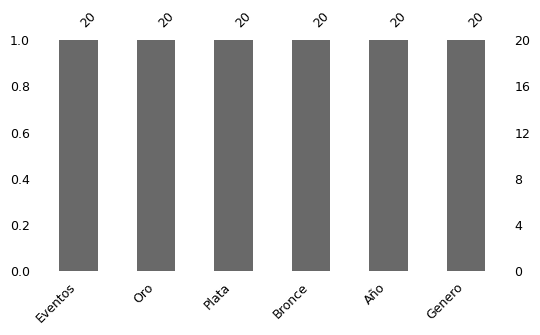

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


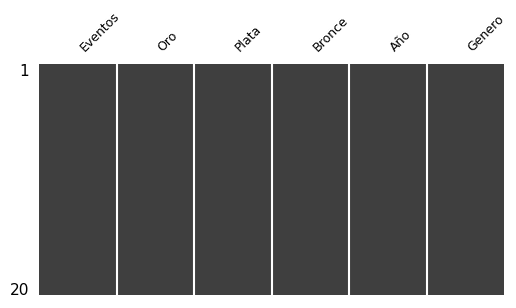

----------------------------------------------------------------------------------------------------


In [6]:
for k, v in dict_datos.items():
    print(f'################################ {k} ################################')
    exploracion_inicial(v)

## Paso 4. Crear un único dataframe con los datos de 2019 y 2020

In [7]:
# Copias df originales para no machacar datos
df_2019 = dict_datos['2019'].copy()
df_2020 = dict_datos['2020'].copy()

In [8]:
# Verificar nulos antes de concatenar
print("Nulos df_2019:")
print(df_2019.isnull().sum())

print("\nNulos df_2020:")
print(df_2020.isnull().sum())

Nulos df_2019:
Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

Nulos df_2020:
Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64


### Corregir año df_2020 a 2021. 
Nota Wikipedia:  "Originalmente el campeonato estaba planeado realizarse en abril de 2020,​ pero debido a la pandemia de COVID-19 el evento fue pospuesto para finales de octubre, y posteriormente para 2021"

In [9]:
df_2020['Año'] = df_2020['Año'].replace(2020, 2021)

print(f"Año df_2020 actualizado: {df_2020['Año'].unique()}")


Año df_2020 actualizado: [2021]


### Concatenar los DF

In [10]:
df = pd.concat([df_2019, df_2020], ignore_index=True)

In [11]:
df.shape

(40, 6)

In [12]:
df['Año'].value_counts()

Año
2019    20
2021    20
Name: count, dtype: int64

## Paso 5. Transformar los datos

Transforma el DataFrame para tener las siguientes columnas: Eventos, Año, Genero, Medalla (que indica si es Oro, Plata o Bronce) y Atleta (que contiene la información del atleta correspondiente)

In [13]:
df.head(5)

,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​,2019,Masculino
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282,2019,Masculino
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculino
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335,2019,Masculino
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354,2019,Masculino


In [14]:
df.tail(5)

,Eventos,Oro,Plata,Bronce,Año,Genero
35,71 kg (07.04),Emily Godley Reino Unido 98 + 129 = 227,Alessia Durante Italia 97 + 122 = 219,Raluca Olaru Rumania 98 + 120 = 218,2021,Femenino
36,76 kg (08.04),Iryna Deja Ucrania 113 + 135 = 248,Yana Sotiyeva Rusia 112 + 134 = 246,Anastasiya Romanova Rusia 111 + 132 = 243,2021,Femenino
37,81 kg (09.04),Alina Marushchak Ucrania 109 + 127 = 236,Gaëlle Nayo-Ketchanke Francia 100 + 131 = 231,Liana Guiurdzhian Armenia 98 + 129 = 227,2021,Femenino
38,87 kg (10.04),Daria Ajmerova Rusia 108 + 138 = 246,Elena Cîlcic Moldavia 107 + 138 = 245,Daria Riazanova Rusia 105 + 135 = 240,2021,Femenino
39,+87 kg (11.04),Emily Campbell Reino Unido 122 + 154 = 276,Anastasiya Lysenko Ucrania 116 + 136 = 252,Melike Günal Turquía 108 + 135 = 243,2021,Femenino


Formato inicial:

| Eventos | Oro | Plata | Bronce | Año | Género |
|---------|-----|-------|--------|-----|--------|

**¡Importante!**
El dataframe final debe tener este formato:

| Eventos | Año | Genero | Medalla | Atleta |
|---------|-----|-------|--------|-----|

### 5.1 Transformar formato con melt

In [15]:
df = df.melt(
    id_vars = ['Eventos', 'Año', 'Genero'],
    value_vars = ['Oro', 'Plata', 'Bronce'],
    var_name = 'Medalla',
    value_name = 'Atleta'
)

df = df.reset_index(drop=True)
print(f"Shape después de melt: {df.shape}")
df.head(10)

Shape después de melt: (120, 5)


,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356
5,89 kg (11.04),2019,Masculino,Oro,Hakob Mkrtchian Armenia 164 + 207 = 371
6,96 kg (12.04),2019,Masculino,Oro,Yauheni Tsijantsou Bielorrusia 178 + 222 = 400
7,102 kg (13.04),2019,Masculino,Oro,Dmytro Chumak Ucrania 175 + 216 = 391
8,109 kg (13.04),2019,Masculino,Oro,Simon Martirosian Armenia 192 + 235 = 427
9,+109 kg (13.04),2019,Masculino,Oro,Lasha Talajadze Georgia 218 + 260 = 478


### 5.2 Detectar inconsistencias en los datos

In [ ]:
# Valores únicos df. Eventos 2 valores repetidos por misma fecha y categoría.
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

Eventos: 39 valores únicos
Año: 2 valores únicos
Genero: 2 valores únicos
Medalla: 3 valores únicos
Atleta: 120 valores únicos


In [17]:
# Ejemplo de Atleta.
print(df['Atleta'].iloc[0])

Mirco Scarantino Italia  116 + 145 = 261[n 1]​


In [18]:
# Detectar corchetes en df
print("Filas con corchetes por columna:")
for col in df.columns:
    if df[col].dtype == 'object':
        cantidad = df[col].str.contains('\[', na=False).sum()
        if cantidad > 0:
            print(f"{col}: {cantidad} filas")


Filas con corchetes por columna:
Eventos: 3 filas
Atleta: 13 filas


In [19]:
# Ver filas con corchetes. Str con valores de [n 1], [n2] o [2] observados en el df
df[df['Atleta'].str.contains('\[', na=False)]['Atleta'].head()

0     Mirco Scarantino Italia  116 + 145 = 261[n 1]​
10       Şaziye Erdoğan Turquía  75 + 88 = 163[n 1]​
20      Anguel Rusev Bulgaria  111 + 147 = 258[n 1]​
30      Nadezhda Nguen Bulgaria  72 + 83 = 155[n 1]​
40      Anguel Rusev Bulgaria  110 + 146 = 256[n 1]​
Name: Atleta, dtype: object

### 5.3 Limpiar datos

### Corchetes

In [20]:
# Función para limpiar corchetes
def limpiar_corchetes(texto):
    '''Elimina todo lo que esté entre corchetes [...]'''
    texto_limpio = re.sub(r'\[.*?\]', '', str(texto))
    return texto_limpio.strip()

### Espacios dobles

In [21]:
# Función para limpiar espacios dobles
def limpiar_espacios(texto):
    '''Elimina espacios dobles y espacios al inicio/final'''
    texto_limpio = str(texto)
    while '  ' in texto_limpio:
        texto_limpio = texto_limpio.replace('  ', ' ')
    return texto_limpio.strip()

In [22]:
# Función para limpiar caracteres invisibles
def limpiar_invisibles(texto):
    '''Elimina caracteres invisibles como \u200b'''
    return str(texto).replace('\u200b', '').strip()

In [23]:
# Aplicar limpieza a todas las columnas de texto
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].apply(limpiar_corchetes)
        df[col] = df[col].apply(limpiar_espacios)
        df[col] = df[col].apply(limpiar_invisibles)

print('Limpieza completada')

Limpieza completada


In [24]:
# Verificar
print('Verificación:')
for col in df.columns:
    if df[col].dtype == 'object':
        corchetes = df[col].str.contains('\[', na=False).sum()
        espacios = df[col].str.contains('  ', na=False).sum()
        invisibles = df[col].str.contains('\u200b', na=False).sum()
        print(f'{col}: corchetes={corchetes}, espacios_dobles={espacios}, invisibles= {invisibles}')

Verificación:
Eventos: corchetes=0, espacios_dobles=0, invisibles= 0
Genero: corchetes=0, espacios_dobles=0, invisibles= 0
Medalla: corchetes=0, espacios_dobles=0, invisibles= 0
Atleta: corchetes=0, espacios_dobles=0, invisibles= 0


In [25]:
df.head()

,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356


## Paso 6. Creación de columnas


- Fecha
- Nombre
- Apellido
- País
- Categoría
- Arrancada
- Dos tiempos
- Total

** Eventos = kg(categoria) + fecha//Año// Género// Medalla= Oro + Plata + Bronce// Atleta= Nombre + Apellido + País + Arrancada + Dos tiempos + Total**

In [ ]:
# Patrón atleta
valor = df['Atleta'].iloc[0]
print(f"Atleta: {valor}")

patron_letras = '[a-zA-Z]+'
patron_numeros = '\d+'

print(f"Letras: {re.findall(patron_letras, valor)}")
print(f"Números: {re.findall(patron_numeros, valor)}")

# Patrón letras: Nombre[1] + Apellido(s)[2]/[3] + País /[-1]
# Patrón números:  Arrancada[1] + Dos tiempos[2] + Total[3]/[-1]

Atleta: Mirco Scarantino Italia 116 + 145 = 261
Letras: ['Mirco', 'Scarantino', 'Italia']
Números: ['116', '145', '261']


### 6.1 Extraer Fecha y categoría de la columna eventos

In [27]:
# Extraer Fecha (entre paréntesis)
def extraer_fecha(texto):
    resultado = re.search('\((\d{2}\.\d{2})\)', str(texto))
    return resultado.group(1) if resultado else None

df['Fecha'] = df['Eventos'].apply(extraer_fecha) + '.' + df['Año'].astype(str)

In [28]:
# Extraer Categoría (número + kg)
def extraer_categoria(texto):
    resultado = re.search('([+]?\d+)\s*kg', str(texto))
    return resultado.group(1) if resultado else None

df['Categoría'] = df['Eventos'].apply(extraer_categoria)

In [29]:
df[['Eventos', 'Fecha', 'Categoría']].head()

,Eventos,Fecha,Categoría
0,55 kg (06.04),06.04.2019,55
1,61 kg (07.04),07.04.2019,61
2,67 kg (08.04),08.04.2019,67
3,73 kg (09.04),09.04.2019,73
4,81 kg (10.04),10.04.2019,81


In [30]:
df.dtypes

Eventos      object
Año           int64
Genero       object
Medalla      object
Atleta       object
Fecha        object
Categoría    object
dtype: object

### 6.2 Extraer información de Atleta

In [31]:
# Normalizo 'Reino Unido' a 'UK' antes de extraer datos para no tener dos palabras para país y que 'Unido' salga en los apellidos
df['Atleta'] = df['Atleta'].str.replace('Reino Unido', 'UK')

In [32]:
# Extraer números patrón atleta
def extraer_numeros_atleta(texto):
    numeros = re.findall(r'\d+', str(texto))
    
    arrancada = int(numeros[0]) if len(numeros) > 0 else None
    dos_tiempos = int(numeros[1]) if len(numeros) > 1 else None
    total = int(numeros[2]) if len(numeros) > 2 else None
    
    return pd.Series([arrancada, dos_tiempos, total])

In [33]:
# Extraer letras patrón atleta
def extraer_texto_atleta(texto):
    texto = str(texto)

    match = re.search(r'\d', texto)

    if match:
        parte_texto = texto[:match.start()].strip()
    else:
        parte_texto = texto.strip()

    palabras = parte_texto.split()

    if len(palabras) >= 3:
        nombre = palabras[0]
        apellidos = ' '.join(palabras[1:-1])
        pais = palabras[-1]
    elif len(palabras) == 2:
        nombre = palabras[0]
        apellidos = ''
        pais = palabras[1]
    else:
        nombre = palabras[0] if palabras else ''
        apellidos = ''
        pais = ''

    return pd.Series([nombre, apellidos, pais])

In [34]:
df[['Arrancada', 'Dos tiempos', 'Total']] = df['Atleta'].apply(extraer_numeros_atleta)
df[['Nombre', 'Apellido', 'País']] = df['Atleta'].apply(extraer_texto_atleta)

In [35]:
# Reino Unido fue cambiado a UK para facilitar la extracción de los países
df['País'].unique()

array(['Italia', 'Bielorrusia', 'Francia', 'Bulgaria', 'Armenia',
       'Ucrania', 'Georgia', 'Turquía', 'Rumania', 'Polonia', 'Letonia',
       'Rusia', 'Alemania', 'Azerbaiyán', 'UK', 'Albania', 'España',
       'Bélgica', 'Moldavia', 'Suecia', 'Austria'], dtype=object)

In [36]:
# Renombro UK a Reino Unido para mejor lectura de los resultados
df['País'] = df['País'].replace({'UK': 'Reino Unido'})

In [37]:
df['País'].value_counts()

País
Rusia          20
Armenia        14
Bulgaria       10
Georgia         9
Bielorrusia     9
Rumania         9
Turquía         9
Ucrania         8
Italia          6
Reino Unido     6
Francia         3
Letonia         3
Alemania        2
Moldavia        2
Azerbaiyán      2
Albania         2
Bélgica         2
Polonia         1
España          1
Suecia          1
Austria         1
Name: count, dtype: int64

In [38]:
df.head()

,Eventos,Año,Genero,Medalla,Atleta,Fecha,Categoría,Arrancada,Dos tiempos,Total,Nombre,Apellido,País
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261,06.04.2019,55,116,145,261,Mirco,Scarantino,Italia
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286,07.04.2019,61,133,153,286,Henadz,Laptseu,Bielorrusia
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312,08.04.2019,67,137,175,312,Bernardin,Matam,Francia
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345,09.04.2019,73,153,192,345,Bozhidar,Andreev,Bulgaria
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356,10.04.2019,81,155,201,356,Antonino,Pizzolato,Italia


## Paso 7. Filtrado de columnas y ordenación

**¡Importante!**
El dataframe final debe contener exclusivamente las siguientes columnas:

| Género    | Categoría | Fecha | Medalla | Nombre | Apellido | País | Arrancada | Dos tiempos | Total |
|-----------|-----------|-------|---------|--------|----------|------|-----------|-------------|-------|

In [39]:
columnas_finales = ['Genero', 'Categoría', 'Fecha', 'Medalla', 'Nombre', 'Apellido', 'País', 'Arrancada', 'Dos tiempos', 'Total']
df = df[columnas_finales]
df.head()

,Genero,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Masculino,55,06.04.2019,Oro,Mirco,Scarantino,Italia,116,145,261
1,Masculino,61,07.04.2019,Oro,Henadz,Laptseu,Bielorrusia,133,153,286
2,Masculino,67,08.04.2019,Oro,Bernardin,Matam,Francia,137,175,312
3,Masculino,73,09.04.2019,Oro,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculino,81,10.04.2019,Oro,Antonino,Pizzolato,Italia,155,201,356


## Paso 8. Tipo de datos

**¡Importante!**
Los tipos de las columnas deben ser los siguientes:

- **Género**: `object`
- **Categoría**: `category`
- **Fecha**: `datetime64[ns]`
- **Medalla**: `category`
- **Nombre**: `object`
- **Apellido**: `object`
- **País**: `object`
- **Arrancada**: `int64`
- **Dos tiempos**: `int64`
- **Total**: `int64`

In [40]:
# Cambiar tipos datos de Categoría/Fecha/Medalla
df.dtypes

Genero         object
Categoría      object
Fecha          object
Medalla        object
Nombre         object
Apellido       object
País           object
Arrancada       int64
Dos tiempos     int64
Total           int64
dtype: object

In [41]:
categorias_u = df['Categoría'].unique().tolist()
medallas_u = df['Medalla'].unique().tolist()
print(f"Categorías: {categorias_u}")
print(f"Medallas: {medallas_u}")

Categorías: ['55', '61', '67', '73', '81', '89', '96', '102', '109', '+109', '45', '49', '59', '64', '71', '76', '87', '+87']
Medallas: ['Oro', 'Plata', 'Bronce']


In [42]:
# Función organizar categorías por peso
def ordenar_categorias(categ):
    def peso(c):
        if c.endswith('+'):
            return (int(c[:-1]), 1)  
        else:
            return (int(c), 0)       

    return sorted(categ, key=peso)

categorias_ord = ordenar_categorias(categorias_u)
categorias_ord

['45',
 '49',
 '55',
 '59',
 '61',
 '64',
 '67',
 '71',
 '73',
 '76',
 '81',
 '87',
 '+87',
 '89',
 '96',
 '102',
 '109',
 '+109']

In [43]:
# Convertir tipos datos
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y')
df['Categoría'] = pd.Categorical(df['Categoría'], categories=categorias_ord, ordered=True)
df['Medalla'] = pd.Categorical(df['Medalla'], categories=['Oro', 'Plata', 'Bronce'], ordered=True)
df['Arrancada'] = df['Arrancada'].astype('int64')
df['Dos tiempos'] = df['Dos tiempos'].astype('int64')
df['Total'] = df['Total'].astype('int64')

df.dtypes

Genero                 object
Categoría            category
Fecha          datetime64[ns]
Medalla              category
Nombre                 object
Apellido               object
País                   object
Arrancada               int64
Dos tiempos             int64
Total                   int64
dtype: object

## Paso 9. Ordendar
**¡Importante!**
El conjunto de datos debe estar ordenado por las siguientes columnas:
['Genero', 'Categoria', 'Medalla']. La siguiente imagen es un ejemplo:

| Genero   | Categoria | Fecha      | Medalla | Nombre    | Apellido | País      | Arrancada | Dos tiempos | Total |
|----------|-----------|------------|---------|-----------|----------|-----------|-----------|-------------|-------|
| Femenino | 45        | 2020-04-03 | Oro     | Nadezhda  | Nguen    | Bulgaria  | 72        | 83          | 155   |
| Femenino | 45        | 2020-04-03 | Plata   | Ivana     | Petrova  | Bulgaria  | 67        | 85          | 152   |
| Femenino | 45        | 2020-04-03 | Bronce  | Melisa    | Güneş    | Turquía   | 68        | 83          | 151   |
| Femenino | 49        | 2020-04-03 | Oro     | Monica    | Csengeri | Rumania   | 86        | 103         | 189   |
| Femenino | 49        | 2020-04-03 | Plata   | Kristina  | Sobol    | Rusia     | 85        | 96          | 181   |


In [44]:
df = df.sort_values(by=['Genero', 'Categoría', 'Medalla']).reset_index(drop=True)
print(df.shape)
df.head(15)

(120, 10)


,Genero,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
3,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
4,Femenino,45,2019-04-06,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150
5,Femenino,45,2021-04-03,Bronce,Melisa,Güneş,Turquía,68,83,151
6,Femenino,49,2019-04-06,Oro,Elena,Andrieș,Rumania,87,103,190
7,Femenino,49,2021-04-03,Oro,Monica,Csengeri,Rumania,86,103,189
8,Femenino,49,2019-04-06,Plata,Kristina,Sobol,Rusia,85,95,180
9,Femenino,49,2021-04-03,Plata,Kristina,Sobol,Rusia,85,96,181


## Paso 10. EDA
Realiza un análisis exploratorio de los datos que te permita ganar conocimiento sobre el conjunto de datos antes de resolver a las preguntas

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Genero       120 non-null    object        
 1   Categoría    120 non-null    category      
 2   Fecha        120 non-null    datetime64[ns]
 3   Medalla      120 non-null    category      
 4   Nombre       120 non-null    object        
 5   Apellido     120 non-null    object        
 6   País         120 non-null    object        
 7   Arrancada    120 non-null    int64         
 8   Dos tiempos  120 non-null    int64         
 9   Total        120 non-null    int64         
dtypes: category(2), datetime64[ns](1), int64(3), object(4)
memory usage: 8.7+ KB


## 10.1 Univariable

### Variables numéricas: Arrancada, Dos tiempo, Total

In [46]:
df.describe()

,Fecha,Arrancada,Dos tiempos,Total
count,120,120.000000,120.000000,120.000000
mean,2020-04-07 21:36:00,129.600000,157.391667,286.991667
min,2019-04-06 00:00:00,67.000000,81.000000,150.000000
25%,2019-04-10 00:00:00,99.500000,122.000000,221.750000
50%,2020-04-07 12:00:00,114.500000,145.000000,257.000000
75%,2021-04-07 00:00:00,163.250000,200.000000,366.000000
max,2021-04-11 00:00:00,222.000000,263.000000,485.000000
std,NaN,38.603435,45.187061,83.566257


In [47]:
df.select_dtypes(include = 'number').head()

,Arrancada,Dos tiempos,Total
0,75,88,163
1,72,83,155
2,69,89,158
3,67,85,152
4,69,81,150


In [48]:
lista_columnas_numericas = df.select_dtypes(include = 'number').columns.to_list()

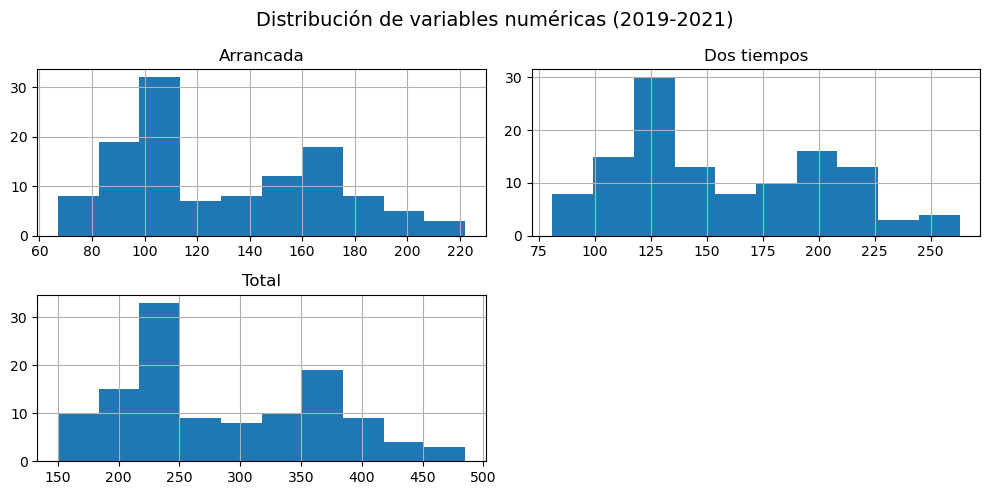

In [49]:
df[lista_columnas_numericas].hist(figsize=(10, 5))
plt.suptitle('Distribución de variables numéricas (2019-2021)', fontsize=14)
plt.tight_layout()
plt.show()

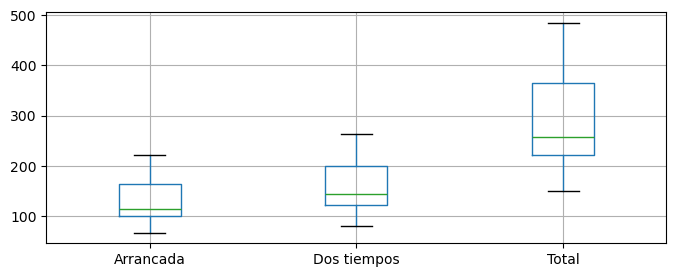

In [50]:
df[lista_columnas_numericas].boxplot(figsize = (8, 3))
plt.show()

### Categóricas: Género, Categoría, Medalla, País

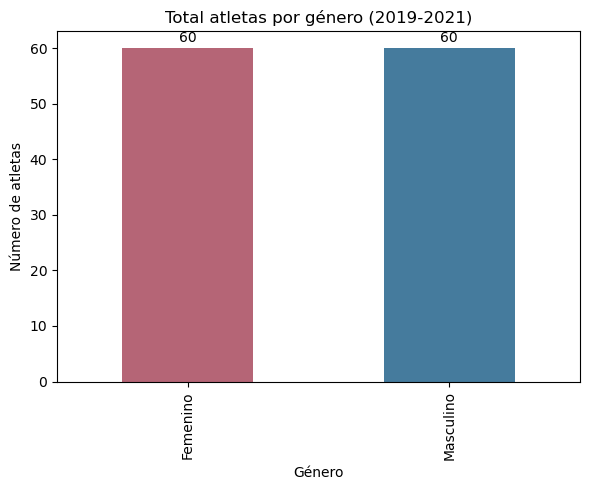

In [108]:
fig, ax = plt.subplots(figsize=(6, 5))

conteo_genero = df['Genero'].value_counts(dropna=False)
conteo_genero.plot(kind='bar', ax=ax, color= ['#B56576', '#457B9D'])

ax.set_title('Total atletas por género (2019-2021)')
ax.set_xlabel('Género')
ax.set_ylabel('Número de atletas')

for i, v in enumerate(conteo_genero.values):
    ax.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

In [52]:
top_genero = (df.sort_values(['Genero', 'Total'], ascending=[True, False]).groupby('Genero').head(15)
[['Nombre', 'Apellido', 'País', 'Genero', 'Categoría', 'Total', 'Medalla']])

top_genero

,Nombre,Apellido,País,Genero,Categoría,Total,Medalla
54,Tatiana,Kashirina,Rusia,Femenino,+87,331,Oro
55,Emily,Campbell,Reino Unido,Femenino,+87,276,Oro
56,Anastasiya,Lysenko,Ucrania,Femenino,+87,268,Plata
58,Emily,Campbell,Reino Unido,Femenino,+87,260,Bronce
57,Anastasiya,Lysenko,Ucrania,Femenino,+87,252,Plata
37,Iryna,Deja,Ucrania,Femenino,76,248,Oro
39,Yana,Sotiyeva,Rusia,Femenino,76,246,Plata
49,Daria,Ajmerova,Rusia,Femenino,87,246,Oro
51,Elena,Cîlcic,Moldavia,Femenino,87,245,Plata
25,Loredana,Toma,Rumania,Femenino,64,244,Oro


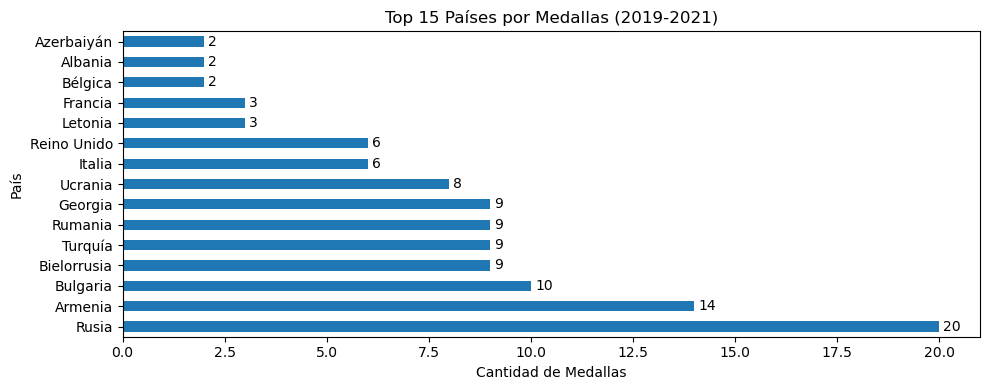

In [53]:
# Gráfico de medallas por país (Top 15)
ax = df['País'].value_counts().head(15).plot(kind='barh', figsize=(10,4))
plt.title('Top 15 Países por Medallas (2019-2021)')
plt.xlabel('Cantidad de Medallas')
plt.ylabel('País')

for i, v in enumerate(df['País'].value_counts().head(15).values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

## 10.2 Bivariable

### País vs medallas oro/plata/bronce

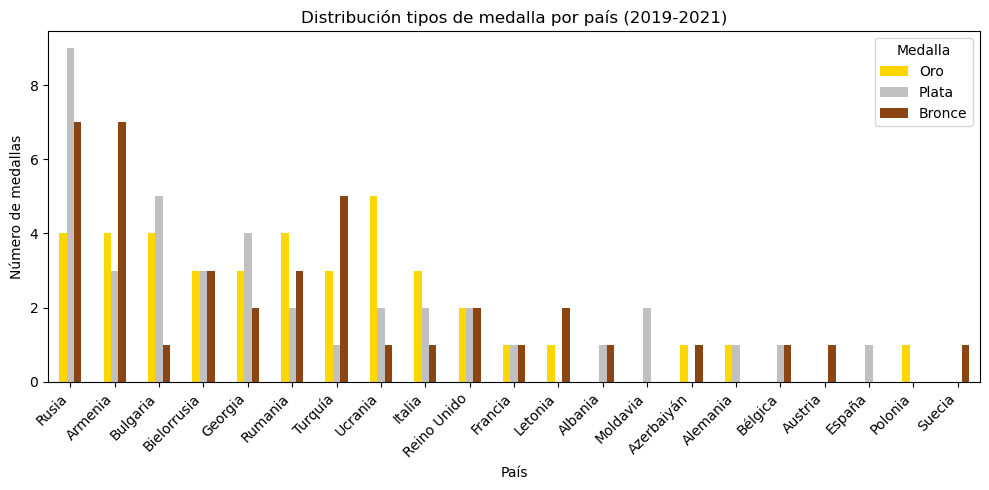

In [54]:
medallas_v = pd.crosstab(df['País'], df['Medalla'])
medallas_v_temp = medallas_v.copy()
medallas_v_temp['Total'] = medallas_v_temp.sum(axis=1)
medallas_v_temp = medallas_v_temp.sort_values('Total', ascending=False)

colores = ['gold', 'silver', 'saddlebrown']

medallas_v_temp[['Oro', 'Plata', 'Bronce']].plot(kind='bar', figsize=(10, 5), color=colores)

plt.title('Distribución tipos de medalla por país (2019-2021)')
plt.xlabel('País')
plt.ylabel('Número de medallas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### País vs género

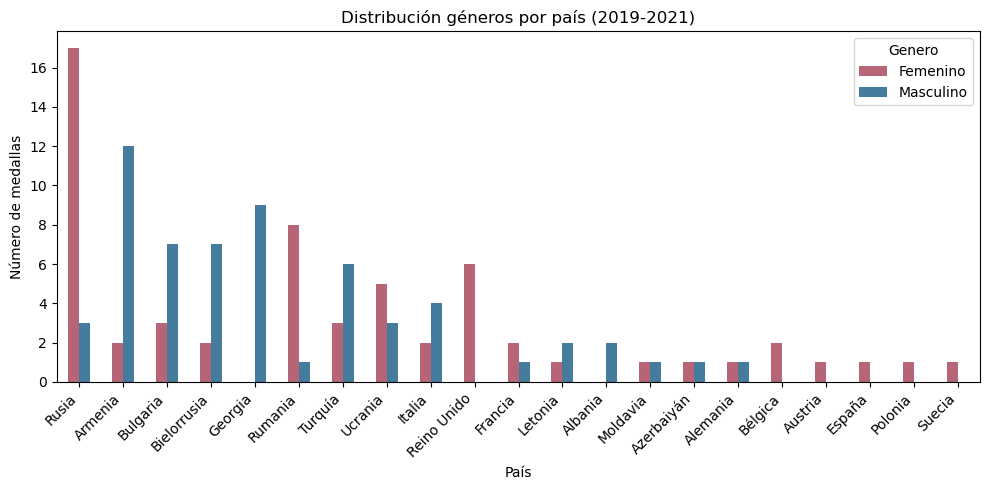

In [55]:
genero_v = pd.crosstab(df['País'], df['Genero'])
genero_v_temp = genero_v.copy()
genero_v_temp['Total'] = genero_v_temp.sum(axis=1)
genero_v_temp = genero_v_temp.sort_values('Total', ascending=False)

colores = ['#B56576', '#457B9D']
genero_v_temp[['Femenino', 'Masculino']].plot(kind='bar', figsize=(10, 5), color=colores)

plt.title('Distribución géneros por país (2019-2021)')
plt.xlabel('País')
plt.ylabel('Número de medallas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [56]:
df.head()

,Genero,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
3,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
4,Femenino,45,2019-04-06,Bronce,Yuliya,Asayonak,Bielorrusia,69,81,150


## **Preguntas obligatorias a resolver**

### ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país en la competición? (Sin considerar el género)

In [57]:
medallas = pd.crosstab(df['País'], df['Medalla'])
medallas['Total'] = medallas.sum(axis=1)
medallas_o = medallas.sort_values('Total', ascending=False)
medallas_o

Medalla,Oro,Plata,Bronce,Total
País,,,,
Rusia,4,9,7,20
Armenia,4,3,7,14
Bulgaria,4,5,1,10
Bielorrusia,3,3,3,9
Georgia,3,4,2,9
Rumania,4,2,3,9
Turquía,3,1,5,9
Ucrania,5,2,1,8
Italia,3,2,1,6


### ¿Qué país ha logrado la mayor equidad en términos de éxito entre sus atletas femeninos y masculinos?

In [58]:
equidad = pd.crosstab(df['País'], df['Genero'])
condicion_e = (equidad['Femenino'] > 0) & (equidad['Masculino'] > 0)
equidad_f = equidad[condicion_e]

equidad_f['Diff'] = abs(equidad_f['Femenino'] - equidad_f['Masculino'])
equidad_o = equidad_f.sort_values('Diff')

min_diff = equidad_o['Diff'].min()
paises_mas_equidad = equidad_o[equidad_o['Diff'] == min_diff]
print(f'Los países con mayor equidad son: {paises_mas_equidad.index.tolist()}')
equidad_o

Los países con mayor equidad son: ['Alemania', 'Azerbaiyán', 'Moldavia']


Genero,Femenino,Masculino,Diff
País,,,
Alemania,1,1,0
Azerbaiyán,1,1,0
Moldavia,1,1,0
Letonia,1,2,1
Francia,2,1,1
Italia,2,4,2
Ucrania,5,3,2
Turquía,3,6,3
Bulgaria,3,7,4


### ¿En qué país es menor la diferencia entre el promedio de puntos totales conseguidos por atletas femeninos y masculinos?

In [59]:
prom = pd.pivot_table(df,values='Total',index='País',columns='Genero',aggfunc='mean')

prom_f = prom.dropna()
prom_f['Diff'] = abs(prom_f['Femenino'] - prom_f['Masculino'])
prom_o = prom_f.sort_values('Diff').round(0).astype(int)

prom_p = prom_o.index[0]
print(f"País con menor diferencia: {prom_p}")
prom_o

País con menor diferencia: Rumania


Genero,Femenino,Masculino,Diff
País,,,
Rumania,213,248,35
Alemania,222,311,89
Francia,220,312,92
Moldavia,245,339,94
Ucrania,242,348,106
Turquía,186,294,108
Italia,198,326,128
Letonia,221,350,130
Bulgaria,155,321,166


# **Fase 2.** Web scraping

## Paso 1. Importar librerías

In [60]:
 import requests
 import pandas as pd
 import numpy as np

## Paso 2. Cargar datos

In [61]:
# Diccionario de estados HTTP
http_status_codes = {
    200: "OK. La petición ha tenido éxito y el servidor ha devuelto el contenido solicitado.",
    301: "Moved Permanently. La URL solicitada se ha movido permanentemente a una nueva ubicación.",
    302: "Found. Indica una redirección temporal a otra URL.",
    401: "Unauthorized. El cliente debe autenticarse para obtener la respuesta solicitada.",
    403: "Forbidden. El servidor comprende la petición, pero se rehúsa a autorizarla.",
    404: "Not Found. El servidor no pudo encontrar el contenido solicitado.",
    500: "Internal Server Error. El servidor encontró una condición inesperada que le impidió completar la solicitud.",
    503: "Service Unavailable. El servidor no está listo para manejar la solicitud, generalmente debido a un mantenimiento o sobrecarga."
}

# Headers para las peticiones
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
}

In [62]:
# Lista de años
# NOTA: No se incluye 2020 porque Wikipedia redirige a 2021 (el campeonato se pospuso por COVID)
min_año = 2019 
max_año = 2024

# Años disponibles: 2019, 2021, 2022, 2023, 2024 (sin 2020)
lista_años = [2019, 2021, 2022, 2023, 2024]
print(f"Años a extraer: {lista_años}")

Años a extraer: [2019, 2021, 2022, 2023, 2024]


In [63]:
# Crear lista de URLs
url_base = 'https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_'
lista_urls = [url_base + str(año) for año in lista_años]
lista_urls

['https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2019',
 'https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2021',
 'https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2022',
 'https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2023',
 'https://es.wikipedia.org/wiki/Campeonato_Europeo_de_Halterofilia_de_2024']

In [64]:
# Extraer datos de Wikipedia
dict_urls = {}

for url in lista_urls:
    valor_año = url[-4:]
    page = requests.get(url, headers=headers)
    print(http_status_codes[page.status_code])
    html = page.text

    ###########################################
    # Leemos las tablas con pd.read_html
    ###########################################
    lista_tablas = pd.read_html(html)
    print(f'Encuentro {len(lista_tablas)} tablas')

    ### Iterar por las tablas extraidas de todas las URLS:
    for v in lista_tablas:
        lista_columns = v.columns.to_list()
        primera_columna = lista_columns[0]
        if primera_columna == 'Evento':
            df_olimpiadas = v.copy()
            df_olimpiadas.columns = ['Eventos', 'Oro', 'Plata', 'Bronce']
            df_olimpiadas['Año'] = int(valor_año)

            if df_olimpiadas['Eventos'].loc[0][:2] == '45':
                df_olimpiadas['Genero'] = 'Femenino'
                dict_urls[valor_año + '_femenino'] = df_olimpiadas
            else:
                df_olimpiadas['Genero'] = 'Masculino'
                dict_urls[valor_año + '_masculino'] = df_olimpiadas
            display(df_olimpiadas.head())

OK. La petición ha tenido éxito y el servidor ha devuelto el contenido solicitado.
Encuentro 10 tablas


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​,2019,Masculino
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282,2019,Masculino
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculino
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335,2019,Masculino
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354,2019,Masculino


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (06.04),Şaziye Erdoğan Turquía 75 + 88 = 163[n 1]​,Ivana Petrova Bulgaria 69 + 89 = 158[n 1]​,Yuliya Asayonak Bielorrusia 69 + 81 = 150[n 1]​,2019,Femenino
1,49 kg (06.04),Elena Andrieș Rumania 87 + 103 = 190,Kristina Sobol Rusia 85 + 95 = 180,Giorgia Russo Italia 75 + 103 = 178,2019,Femenino
2,55 kg (07.04),Joanna Łochowska Polonia 87 + 112 = 199,Svetlana Yershova Rusia 90 + 108 = 198,Kristina Novitskaya Rusia 85 + 105 = 190,2019,Femenino
3,59 kg (08.04),Rebeka Koha Letonia 101 + 120 = 221,Tatiana Aleyeva Rusia 94 + 120 = 214,Alexandra Kozlova Rusia 96 + 117 = 213,2019,Femenino
4,64 kg (09.04),Loredana Toma Rumania 111 + 128 = 239,Irina Lepșa Rumania 102 + 127 = 229,Zoe Smith Reino Unido 96 + 128 = 224,2019,Femenino


OK. La petición ha tenido éxito y el servidor ha devuelto el contenido solicitado.
Encuentro 7 tablas


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Rumania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ucrania 110 + 137 = 247[n 1]​,2021,Masculino
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turquía 130 + 157 = 287,2021,Masculino
2,67 kg (05.04),Muhammed Özbek Turquía 145 + 178 = 323,Mirko Zanni Italia 148 + 170 = 318,Valentin Guenchev Bulgaria 138 + 177 = 315,2021,Masculino
3,73 kg (06.04),Daniyar İsmayilov Turquía 160 + 181 = 341,Marin Robu Moldavia 156 + 183 = 339,Briken Calja Albania 152 + 184 = 336,2021,Masculino
4,81 kg (07.04),Antonino Pizzolato Italia 164 + 206 = 370,Karlos Nasar Bulgaria 163 + 206 = 369,Ritvars Suharevs Letonia 157 + 190 = 347,2021,Masculino


...

,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (16.04),Anguel Rusev Bulgaria 109 + 141 = 250[n 1]​,Ramin Shamilishvili Georgia 113 + 136 = 249[n...,Valentin Iancu Rumania 109 + 136 = 245[n 1]​,2023,Masculino
1,61 kg (16.04),Shota Mishvelidze Georgia 136 + 162 = 298,Sergio Massidda Italia 130 + 162 = 292,Ivan Dimov Bulgaria 127 + 150 = 277,2023,Masculino
2,67 kg (17.04),Gor Sahakian Armenia 145 + 175 = 320,Acorán Hernández Mendoza España 140 + 165 = 305,Kaan Kahriman Turquía 141 + 160 = 301,2023,Masculino
3,73 kg (18.04),Ritvars Suharevs Letonia 152 + 184 = 336,David Sánchez López España 150 + 185 = 335,Mirko Zanni Italia 155 + 180 = 335,2023,Masculino
4,81 kg (19.04),Oscar Reyes Martínez Italia 155 + 188 = 343,Batu Han Yüksel Turquía 152 + 187 = 339,Rafik Harutiunian Armenia 150 + 187 = 337,2023,Masculino


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (15.04),Cansu Bektaş Turquía 72 + 90 = 162[n 1]​,Adriana Pană Rumania 70 + 83 = 153[n 1]​,Marta García Rincón España 68 + 85 = 153[n 1]​,2023,Femenino
1,49 kg (15.04),Mihaela Cambei Rumania 92 + 106 = 198,Giulia Imperio Italia 83 + 100 = 183,Anhelina Lomachynska Ucrania 81 + 95 = 176,2023,Femenino
2,55 kg (16.04),Andreea Cotruță Rumania 91 + 110 = 201,Svitlana Samuliak Ucrania 90 + 109 = 199,Izabella Yailian Armenia 87 + 109 = 196,2023,Femenino
3,59 kg (17.04),Kamila Konotop Ucrania 106 + 129 = 235,Nina Sterckx Bélgica 93 + 116 = 209,Nadiya Shpylka Ucrania 93 +114 = 207,2023,Femenino
4,64 kg (18.04),Nuray Güngör Turquía 99 + 120 = 219,Mariya Hanhur Ucrania 98 + 116 = 214,Zoe Smith Reino Unido 93 + 121 = 214,2023,Femenino


OK. La petición ha tenido éxito y el servidor ha devuelto el contenido solicitado.
Encuentro 7 tablas


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (13.02),Anguel Rusev Bulgaria 109 + 135 = 244[n 1]​,Ramin Shamilishvili Georgia 111 + 130 = 241[n...,Dzhan Zarkov Bulgaria 102 + 133 = 235[n 1]​,2024,Masculino
1,61 kg (13.02),Gabriel Marinov Bulgaria 121 + 160 = 281,Ivan Dimov Bulgaria 130 + 150 = 280,Shota Mishvelidze Georgia 125 + 147 = 272,2024,Masculino
2,67 kg (14.02),Gor Sahakian Armenia 140 + 171 = 311,Kaan Kahriman Turquía 142 + 168 = 310,Ferdi Hardal Turquía 135 + 169 = 304,2024,Masculino
3,73 kg (15.02),Bozhidar Andreev Bulgaria 155 + 193 = 348,Muhammed Özbek Turquía 150 + 186 = 336,Ritvars Suharevs Letonia 154 + 177 = 331,2024,Masculino
4,81 kg (16.02),Oscar Reyes Martínez Italia 155 + 191 = 346,Kristi Ramadani Albania 151 + 190 = 341,Rafik Harutiunian Armenia 154 + 182 = 336,2024,Masculino


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (12.02),Cansu Bektaş Turquía 75 + 88 = 163[n 1]​,Gamze Altun Turquía 65 + 92 = 157[n 1]​,Marta García Rincón España 72 + 84 = 156[n 1]​,2024,Femenino
1,49 kg (12.02),Mihaela Cambei Rumania 90 + 109 = 199,Oliwia Drzazga Polonia 74 + 96 = 170,Tham Nguyen Irlanda 74 + 95 = 169,2024,Femenino
2,55 kg (13.02),Alexandra Grigorian Armenia 81 + 115 = 196,Celine Delia Italia 84 + 111 = 195,Sol Anette Waaler Noruega 86 + 104 = 190,2024,Femenino
3,59 kg (14.02),Kamila Konotop Ucrania 105 + 125 = 230,Dora Tchakounté Francia 98 + 117 = 215,Saara Retulainen Finlandia 95 + 119 = 214,2024,Femenino
4,64 kg (15.02),Hanna Davydova Ucrania 100 + 120 = 220,Svitlana Samuliak Ucrania 101 + 118 = 219,Wiktoria Wołk Polonia 94 + 121 = 215,2024,Femenino


In [65]:
# Verificar cantidad de DataFrames extraídos
print(f"Total DataFrames extraídos: {len(dict_urls)}")
dict_urls.keys()

Total DataFrames extraídos: 10


dict_keys(['2019_masculino', '2019_femenino', '2021_masculino', '2021_femenino', '2022_masculino', '2022_femenino', '2023_masculino', '2023_femenino', '2024_masculino', '2024_femenino'])

## Paso 3. Exploración inicial

################################ 2019_masculino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​,2019,Masculino
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282,2019,Masculino
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculino
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335,2019,Masculino
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354,2019,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,89 kg (11.04),Hakob Mkrtchian Armenia 164 + 207 = 371,Revaz Davitadze Georgia 170 + 200 = 370,Davit Hovhannisian Armenia 165 + 195 = 360,2019,Masculino
6,96 kg (12.04),Yauheni Tsijantsou Bielorrusia 178 + 222 = 400,Yegor Klimonov Rusia 168 + 210 = 378,Anton Pliesnoi Georgia 173 + 204 = 377,2019,Masculino
7,102 kg (13.04),Dmytro Chumak Ucrania 175 + 216 = 391,Samvel Gasparian Armenia 168 + 209 = 377,Vadzim Straltsou Bielorrusia 170 + 206 = 376,2019,Masculino
8,109 kg (13.04),Simon Martirosian Armenia 192 + 235 = 427,Andrei Aramnau Bielorrusia 190 + 221 = 411,Rodion Bochkov Rusia 192 + 218 = 410,2019,Masculino
9,+109 kg (13.04),Lasha Talajadze Georgia 218 + 260 = 478,Irakli Turmanidze Georgia 206 + 241 = 447,Ruben Alexanian Armenia 195 + 245 = 440,2019,Masculino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


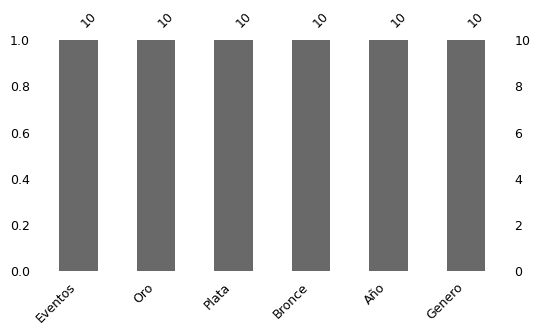

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


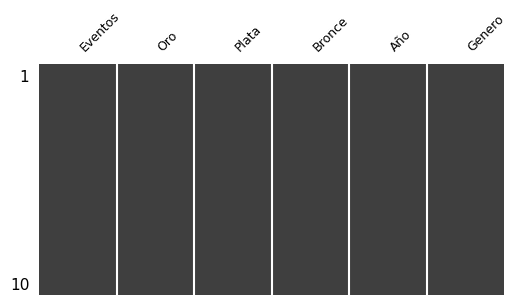

----------------------------------------------------------------------------------------------------
################################ 2019_femenino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (06.04),Şaziye Erdoğan Turquía 75 + 88 = 163[n 1]​,Ivana Petrova Bulgaria 69 + 89 = 158[n 1]​,Yuliya Asayonak Bielorrusia 69 + 81 = 150[n 1]​,2019,Femenino
1,49 kg (06.04),Elena Andrieș Rumania 87 + 103 = 190,Kristina Sobol Rusia 85 + 95 = 180,Giorgia Russo Italia 75 + 103 = 178,2019,Femenino
2,55 kg (07.04),Joanna Łochowska Polonia 87 + 112 = 199,Svetlana Yershova Rusia 90 + 108 = 198,Kristina Novitskaya Rusia 85 + 105 = 190,2019,Femenino
3,59 kg (08.04),Rebeka Koha Letonia 101 + 120 = 221,Tatiana Aleyeva Rusia 94 + 120 = 214,Alexandra Kozlova Rusia 96 + 117 = 213,2019,Femenino
4,64 kg (09.04),Loredana Toma Rumania 111 + 128 = 239,Irina Lepșa Rumania 102 + 127 = 229,Zoe Smith Reino Unido 96 + 128 = 224,2019,Femenino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,71 kg (10.04),Anastasiya Romanova Rusia 112 + 128 = 240,Emily Godley Reino Unido 93 + 123 = 216,Mădălina Molie Rumania 101 + 114 = 215,2019,Femenino
6,76 kg (11.04),Daria Naumava Bielorrusia 106 + 136 = 242,Lidia Valentín[2]​ España 108 + 133 = 241,Patricia Strenius Suecia 101 + 132 = 233,2019,Femenino
7,81 kg[n 2]​ (12.04),Nina Schroth Alemania 102 + 120 = 222,Anna Van Bellinghen Bélgica 103 + 118 = 221,Liana Guiurdzhian Armenia 97 + 120 = 217,2019,Femenino
8,87 kg (12.04),Xeniya Pasjina Rusia 110 + 132 = 242,Diana Mstiyeva Rusia 110 + 130 = 240,Sarah Fischer Austria 102 + 129 = 231,2019,Femenino
9,+87 kg (13.04),Tatiana Kashirina Rusia 146 + 185 = 331,Anastasiya Lysenko Ucrania 120 + 148 = 268,Emily Campbell Reino Unido 115 + 145 = 260,2019,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


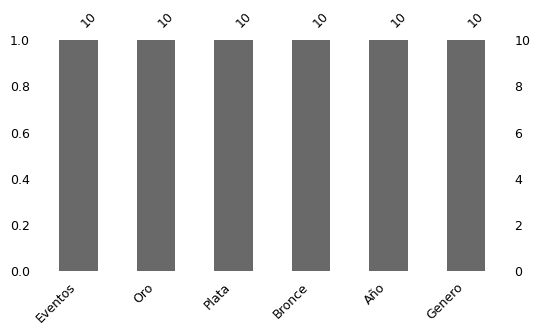

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


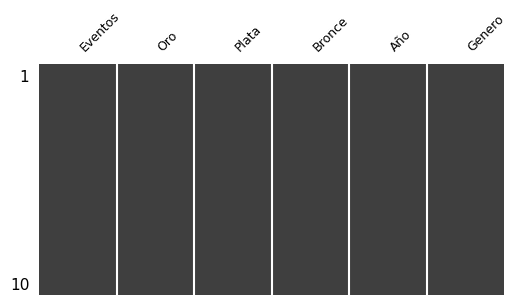

----------------------------------------------------------------------------------------------------
################################ 2021_masculino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (04.04),Anguel Rusev Bulgaria 111 + 147 = 258[n 1]​,Valentin Iancu Rumania 108 + 140 = 248[n 1]​,Dmytro Voronovsky Ucrania 110 + 137 = 247[n 1]​,2021,Masculino
1,61 kg (04.04),Stilian Grozdev Bulgaria 136 + 160 = 296,Shota Mishvelidze Georgia 135 + 155 = 290,Ferdi Hardal Turquía 130 + 157 = 287,2021,Masculino
2,67 kg (05.04),Muhammed Özbek Turquía 145 + 178 = 323,Mirko Zanni Italia 148 + 170 = 318,Valentin Guenchev Bulgaria 138 + 177 = 315,2021,Masculino
3,73 kg (06.04),Daniyar İsmayilov Turquía 160 + 181 = 341,Marin Robu Moldavia 156 + 183 = 339,Briken Calja Albania 152 + 184 = 336,2021,Masculino
4,81 kg (07.04),Antonino Pizzolato Italia 164 + 206 = 370,Karlos Nasar Bulgaria 163 + 206 = 369,Ritvars Suharevs Letonia 157 + 190 = 347,2021,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,89 kg (08.04),Karen Avaguian Armenia 175 + 200 = 375,Revaz Davitadze Georgia 171 + 203 = 374,Andranik Karapetian Armenia 170 + 195 = 365,2021,Masculino
6,96 kg (09.04),Anton Pliesnoi Georgia 180 + 213 = 393,Piotr Asayonak Bielorrusia 172 + 202 = 374,Hakob Mkrtchian Armenia 160 + 212 = 372,2021,Masculino
7,102 kg (10.04),Samvel Gasparian Armenia 176 +214 = 390,Arsen Martirosian Armenia 171 + 209 = 380,Dadaş Dadaşbəyli Azerbaiyán 177 + 202 = 379,2021,Masculino
8,109 kg (10.04),Dmytro Chumak Ucrania 181 + 226 = 407,Jristo Jristov Bulgaria 186 + 220 = 406,Timur Naniyev Rusia 184 + 217 = 401,2021,Masculino
9,+109 kg (11.04),Lasha Talajadze Georgia 222 + 263 = 485,Gor Minasian Armenia 216 + 248 = 464,Varazdat Lalayan Armenia 205 + 240 = 445,2021,Masculino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


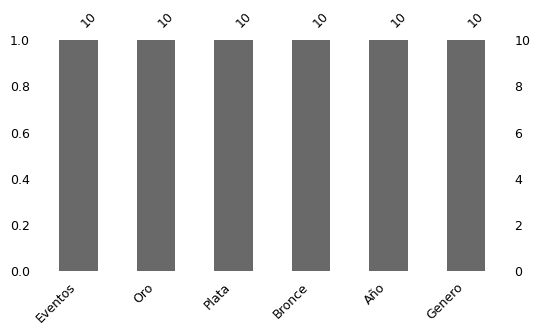

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


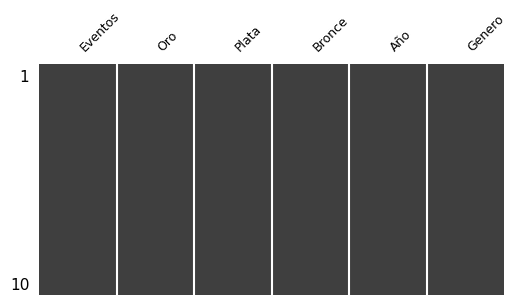

----------------------------------------------------------------------------------------------------
################################ 2021_femenino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (03.04),Nadezhda Nguen Bulgaria 72 + 83 = 155[n 1]​,Ivana Petrova Bulgaria 67 + 85 = 152[n 1]​,Melisa Güneş Turquía 68 + 83 = 151[n 1]​,2021,Femenino
1,49 kg (03.04),Monica Csengeri Rumania 86 + 103 = 189,Kristina Sobol Rusia 85 + 96 = 181,Mihaela Cambei Rumania 80 + 100 = 180,2021,Femenino
2,55 kg (04.04),Kamila Konotop Ucrania 95 + 113 = 208,Svetlana Yershova Rusia 88 + 112 = 200,Nina Sterckx Bélgica 88 + 109 = 197,2021,Femenino
3,59 kg (05.04),Boyanka Kostova Azerbaiyán 95 + 116 = 211,Olga Tio Rusia 95 + 115 = 210,Dora Tchakounté Francia 95 + 115 = 210,2021,Femenino
4,64 kg (06.04),Loredana Toma Rumania 114 + 130 = 244,Sarah Davies Reino Unido 101 + 129 = 230,Anastasiya Anzorova Rusia 100 + 122 = 222,2021,Femenino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,71 kg (07.04),Emily Godley Reino Unido 98 + 129 = 227,Alessia Durante Italia 97 + 122 = 219,Raluca Olaru Rumania 98 + 120 = 218,2021,Femenino
6,76 kg (08.04),Iryna Deja Ucrania 113 + 135 = 248,Yana Sotiyeva Rusia 112 + 134 = 246,Anastasiya Romanova Rusia 111 + 132 = 243,2021,Femenino
7,81 kg (09.04),Alina Marushchak Ucrania 109 + 127 = 236,Gaëlle Nayo-Ketchanke Francia 100 + 131 = 231,Liana Guiurdzhian Armenia 98 + 129 = 227,2021,Femenino
8,87 kg (10.04),Daria Ajmerova Rusia 108 + 138 = 246,Elena Cîlcic Moldavia 107 + 138 = 245,Daria Riazanova Rusia 105 + 135 = 240,2021,Femenino
9,+87 kg (11.04),Emily Campbell Reino Unido 122 + 154 = 276,Anastasiya Lysenko Ucrania 116 + 136 = 252,Melike Günal Turquía 108 + 135 = 243,2021,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


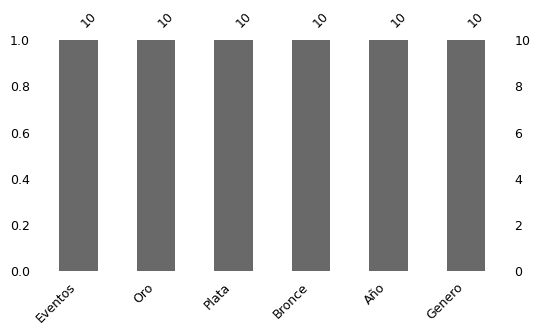

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


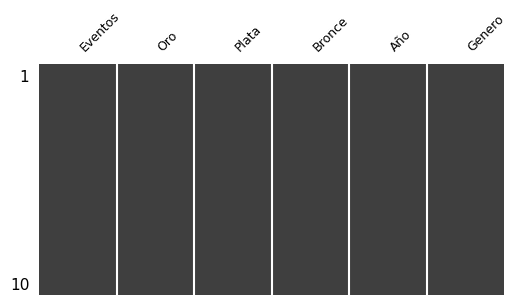

----------------------------------------------------------------------------------------------------
################################ 2022_masculino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (29.05),Anguel Rusev Bulgaria 113 + 144 = 257[n 1]​,Josué Brachi García España 115 + 141 = 256[n 1]​,Dmytro Voronovsky Ucrania 108 + 134 = 242[n 1]​,2022,Masculino
1,61 kg (29.05),Ivan Dimov Bulgaria 135 + 151 = 286,Simon Brandhuber Alemania 134 + 152 = 286,Gabriel Marinov Bulgaria 122 + 157 = 279,2022,Masculino
2,67 kg (30.05),Valentin Guenchev Bulgaria 139 + 175 = 314,Shota Mishvelidze Georgia 142 + 165 = 307,Acorán Hernández Mendoza España 138 + 161 = 299,2022,Masculino
3,73 kg (31.05),Muhammed Özbek Turquía 149 + 190 = 339,Kaji Asanidze Georgia 150 + 176 = 326,Piotr Kudłaszyk Polonia 143 + 181 = 324,2022,Masculino
4,81 kg (01.06),Rafik Harutiunian Armenia 160 + 194 = 354,Andrés Mata Pérez España 160 + 186 = 346,Bozhidar Andreev Bulgaria 153 + 190 = 343,2022,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,89 kg (02.06),Antonino Pizzolato Italia 175 + 217 = 392,Karlos Nasar Bulgaria 171 + 211 = 382,Revaz Davitadze Georgia 171 + 198 = 369,2022,Masculino
6,96 kg (03.06),Davit Hovhannisian Armenia 171 + 206 = 377,Ara Aghanian Armenia 170 + 205 = 375,Romain Imadouchène Francia 160 + 210 = 370,2022,Masculino
7,102 kg (04.06),David Fischerov Bulgaria 177 + 215 = 392,Samvel Gasparian Armenia 176 + 214 = 390,Marcos Ruiz Velasco España 176 + 208 = 384,2022,Masculino
8,109 kg (04.06),Jristo Jristov Bulgaria 180 + 211 = 391,Guiorgui Chjeidze Georgia 174 + 210 = 384,Arsen Martirosian Armenia 170 + 201 = 371,2022,Masculino
9,+109 kg (05.06),Lasha Talajadze Georgia 217 + 245 = 462,Varazdat Lalayan Armenia 211 + 240 = 451,Gor Minasian Armenia 210 + 236 = 446,2022,Masculino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


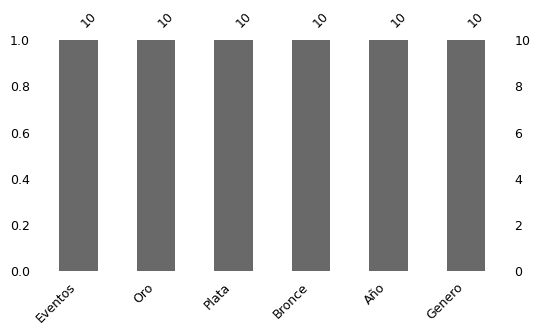

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


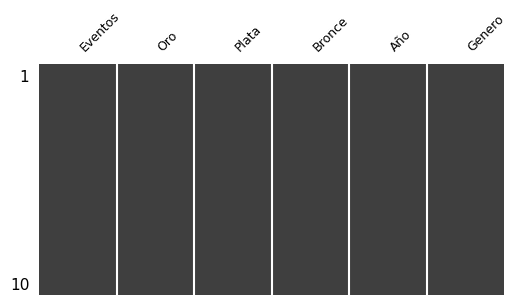

----------------------------------------------------------------------------------------------------
################################ 2022_femenino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (28.05),Şaziye Erdoğan Turquía 73 + 90 = 163[n 1]​,Cansu Bektaş Turquía 68 + 85 = 153[n 1]​,Radmila Zagorac Serbia 68 + 84 = 152[n 1]​,2022,Femenino
1,49 kg (28.05),Giulia Imperio Italia 79 + 92 = 171,Anhelina Lomachynska Ucrania 80 + 87 = 167,María Giménez-Guervos España 72 + 91 = 163,2022,Femenino
2,55 kg (29.05),Evagjelia Veli Albania 95 + 113 = 208,Kamila Konotop Ucrania 94 + 11 = 207,Nina Sterckx Bélgica 94 + 111 = 205,2022,Femenino
3,59 kg (30.05),Dora Tchakounté Francia 96 + 117 = 213,Lucrezia Magistris Italia 98 + 114 = 212,Ine Andersson Noruega 90 + 118 = 208,2022,Femenino
4,64 kg (31.05),Mariya Hanhur Ucrania 102 + 120 = 222,Nuray Güngör Turquía 99 + 120 = 219,Vicky Graillot Francia 89 + 119 = 208,2022,Femenino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,71 kg (01.06),Patricia Strenius Suecia 94 + 130 = 224,Lisa Marie Schweizer Alemania 103 + 120 = 223,Monika Marach Polonia 99 + 116 = 215,2022,Femenino
6,76 kg (02.06),Marie Fegue Francia 110 + 135 = 245,Daniela Ivanova Letonia 96 + 126 = 222,Dilara Ucan Turquía 99 + 121 = 220,2022,Femenino
7,81 kg (03.06),Iryna Deja Ucrania 116 + 137 = 253,Alina Marushchak Ucrania 108 + 127 = 235,Dilara Narin Turquía 99 + 133 = 232,2022,Femenino
8,87 kg (04.06),Solfrid Koanda Noruega 109 + 143 = 252,Anastasiya Manievska Ucrania 107 + 130 = 237,Anastasiya Hotfrid Georgia 106 + 129 = 235,2022,Femenino
9,+87 kg (05.06),Emily Campbell Reino Unido 118 + 153 = 271,Melike Günal Turquía 108 + 134 = 242,Sarah Fischer Austria 102 + 128 = 230,2022,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


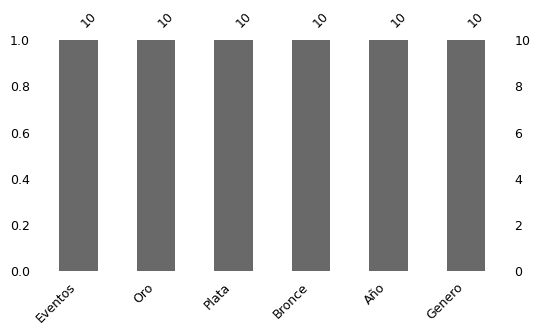

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


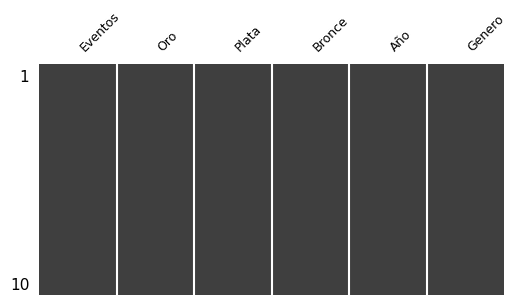

----------------------------------------------------------------------------------------------------
################################ 2023_masculino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (16.04),Anguel Rusev Bulgaria 109 + 141 = 250[n 1]​,Ramin Shamilishvili Georgia 113 + 136 = 249[n...,Valentin Iancu Rumania 109 + 136 = 245[n 1]​,2023,Masculino
1,61 kg (16.04),Shota Mishvelidze Georgia 136 + 162 = 298,Sergio Massidda Italia 130 + 162 = 292,Ivan Dimov Bulgaria 127 + 150 = 277,2023,Masculino
2,67 kg (17.04),Gor Sahakian Armenia 145 + 175 = 320,Acorán Hernández Mendoza España 140 + 165 = 305,Kaan Kahriman Turquía 141 + 160 = 301,2023,Masculino
3,73 kg (18.04),Ritvars Suharevs Letonia 152 + 184 = 336,David Sánchez López España 150 + 185 = 335,Mirko Zanni Italia 155 + 180 = 335,2023,Masculino
4,81 kg (19.04),Oscar Reyes Martínez Italia 155 + 188 = 343,Batu Han Yüksel Turquía 152 + 187 = 339,Rafik Harutiunian Armenia 150 + 187 = 337,2023,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,89 kg (20.04),Karlos Nasar Bulgaria 174 + 221 = 395,Andranik Karapetian Armenia 178 + 196 = 374,Marin Robu Moldavia 166 + 198 = 364,2023,Masculino
6,96 kg (21.04),Davit Hovhannisian Armenia 172 + 205 = 377,Ara Aghanian Armenia 165 + 199 = 364,Cristiano Ficco Italia 165 + 198 = 363,2023,Masculino
7,102 kg (22.04),Garik Karapetian Armenia 178 + 214 = 392,Irakli Chjeidze Georgia 173 + 214 = 387,Tudor Bratu Moldavia 170 + 204 = 374,2023,Masculino
8,109 kg (22.04),Samvel Gasparian Armenia 175 + 220 = 395,Guiorgui Chjeidze Georgia 173 + 208 = 381,Petros Petrosian Armenia 165 + 214 = 379,2023,Masculino
9,+109 kg (23.04),Lasha Talajadze Georgia 222 + 252 = 474,Varazdat Lalayan Armenia 212 + 250 = 462,Simon Martirosian Armenia 195 + 245 = 440,2023,Masculino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


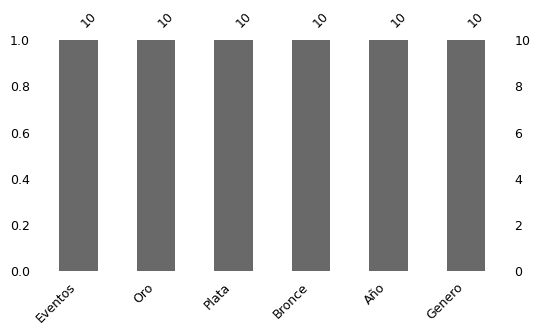

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


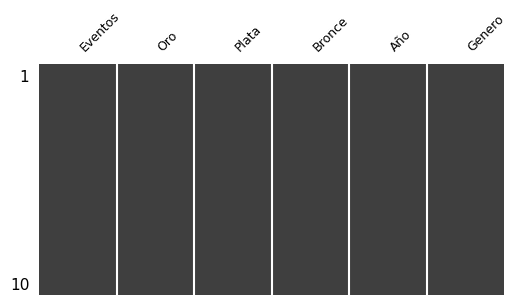

----------------------------------------------------------------------------------------------------
################################ 2023_femenino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (15.04),Cansu Bektaş Turquía 72 + 90 = 162[n 1]​,Adriana Pană Rumania 70 + 83 = 153[n 1]​,Marta García Rincón España 68 + 85 = 153[n 1]​,2023,Femenino
1,49 kg (15.04),Mihaela Cambei Rumania 92 + 106 = 198,Giulia Imperio Italia 83 + 100 = 183,Anhelina Lomachynska Ucrania 81 + 95 = 176,2023,Femenino
2,55 kg (16.04),Andreea Cotruță Rumania 91 + 110 = 201,Svitlana Samuliak Ucrania 90 + 109 = 199,Izabella Yailian Armenia 87 + 109 = 196,2023,Femenino
3,59 kg (17.04),Kamila Konotop Ucrania 106 + 129 = 235,Nina Sterckx Bélgica 93 + 116 = 209,Nadiya Shpylka Ucrania 93 +114 = 207,2023,Femenino
4,64 kg (18.04),Nuray Güngör Turquía 99 + 120 = 219,Mariya Hanhur Ucrania 98 + 116 = 214,Zoe Smith Reino Unido 93 + 121 = 214,2023,Femenino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,71 kg (19.04),Loredana Toma Rumania 110 + 130 = 240,Giulia Miserendino Italia 105 + 125 = 230,Sarah Davies Reino Unido 100 + 126 = 226,2023,Femenino
6,76 kg (20.04),Marie Fegue Francia 113 + 140 = 253,Tatev Hakobian Armenia 104 + 122 = 226,Daniela Ivanova Letonia 96 + 126 = 222,2023,Femenino
7,81 kg (21.04),Iryna Deja Ucrania 123 + 135 = 258,Dilara Narin Turquía 101 + 134 = 235,Elena Erighina Moldavia 104 + 130 = 234,2023,Femenino
8,87 kg (22.04),Solfrid Koanda Noruega 117 + 155 = 272,Anastasiya Manievska Ucrania 108 + 130 = 238,Hripsime Jurshudian Armenia 107 + 120 = 227,2023,Femenino
9,+87 kg (23.04),Emily Campbell Reino Unido 110 + 143 = 253,Anastasiya Hotfrid Georgia 117+ 135 = 252,Valentyna Kisil Ucrania 111 + 133 = 244,2023,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


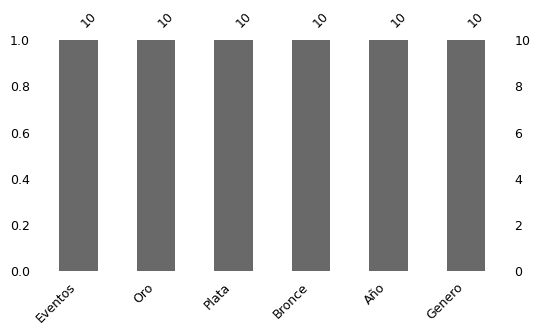

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


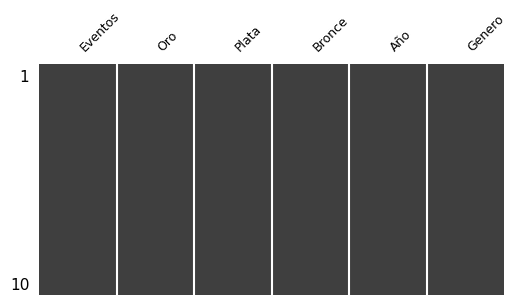

----------------------------------------------------------------------------------------------------
################################ 2024_masculino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (13.02),Anguel Rusev Bulgaria 109 + 135 = 244[n 1]​,Ramin Shamilishvili Georgia 111 + 130 = 241[n...,Dzhan Zarkov Bulgaria 102 + 133 = 235[n 1]​,2024,Masculino
1,61 kg (13.02),Gabriel Marinov Bulgaria 121 + 160 = 281,Ivan Dimov Bulgaria 130 + 150 = 280,Shota Mishvelidze Georgia 125 + 147 = 272,2024,Masculino
2,67 kg (14.02),Gor Sahakian Armenia 140 + 171 = 311,Kaan Kahriman Turquía 142 + 168 = 310,Ferdi Hardal Turquía 135 + 169 = 304,2024,Masculino
3,73 kg (15.02),Bozhidar Andreev Bulgaria 155 + 193 = 348,Muhammed Özbek Turquía 150 + 186 = 336,Ritvars Suharevs Letonia 154 + 177 = 331,2024,Masculino
4,81 kg (16.02),Oscar Reyes Martínez Italia 155 + 191 = 346,Kristi Ramadani Albania 151 + 190 = 341,Rafik Harutiunian Armenia 154 + 182 = 336,2024,Masculino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,89 kg (17.02),Karlos Nasar Bulgaria 176 + 215 = 391,Antonino Pizzolato Italia 170 + 210 = 380,Marin Robu Moldavia 171+ 207 = 378,2024,Masculino
6,96 kg (18.02),Hakob Mkrtchian Armenia 166 + 209 = 375,Davit Hovhannisian Armenia 169 + 205 = 374,Pavel Jadasevich AIN[a 1]​ 165 + 195 = 360,2024,Masculino
7,102 kg (19.02),Yauheni Tsijantsou AIN[a 1]​ 181 + 217 = 398,Samvel Gasparian Armenia 180 + 216 = 396,Garik Karapetian Armenia 182 + 212 = 394,2024,Masculino
8,109 kg (19.02),Dadaş Dadaşbəyli Azerbaiyán 176 + 212 = 388,Jristo Jristov Bulgaria 175 + 205 = 380,Matthäus Hofmann Alemania 172 + 206 = 378,2024,Masculino
9,+109 kg (20.02),Varazdat Lalayan Armenia 205 + 250 = 455,Simon Martirosian Armenia 190 + 247 = 437,Eduard Ziaziulin AIN[a 1]​ 195 + 241 = 436,2024,Masculino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


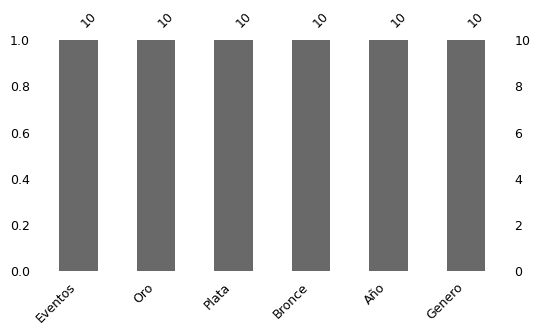

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


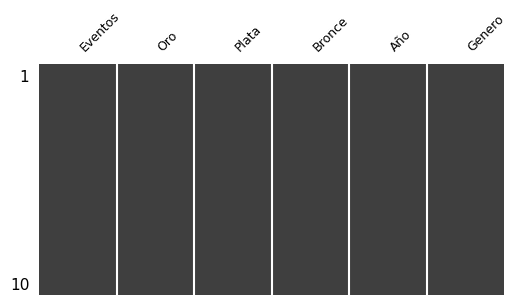

----------------------------------------------------------------------------------------------------
################################ 2024_femenino ################################
¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 10 filas y 6 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
0,45 kg (12.02),Cansu Bektaş Turquía 75 + 88 = 163[n 1]​,Gamze Altun Turquía 65 + 92 = 157[n 1]​,Marta García Rincón España 72 + 84 = 156[n 1]​,2024,Femenino
1,49 kg (12.02),Mihaela Cambei Rumania 90 + 109 = 199,Oliwia Drzazga Polonia 74 + 96 = 170,Tham Nguyen Irlanda 74 + 95 = 169,2024,Femenino
2,55 kg (13.02),Alexandra Grigorian Armenia 81 + 115 = 196,Celine Delia Italia 84 + 111 = 195,Sol Anette Waaler Noruega 86 + 104 = 190,2024,Femenino
3,59 kg (14.02),Kamila Konotop Ucrania 105 + 125 = 230,Dora Tchakounté Francia 98 + 117 = 215,Saara Retulainen Finlandia 95 + 119 = 214,2024,Femenino
4,64 kg (15.02),Hanna Davydova Ucrania 100 + 120 = 220,Svitlana Samuliak Ucrania 101 + 118 = 219,Wiktoria Wołk Polonia 94 + 121 = 215,2024,Femenino


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Eventos,Oro,Plata,Bronce,Año,Genero
5,71 kg (16.02),Loredana Toma Rumania 114 + 127 = 241,Siuzanna Valodzka AIN[a 1]​ 105 + 130 = 235,Lisa Marie Schweizer Alemania 107 + 124 = 231,2024,Femenino
6,76 kg (17.02),Genna Toko Kegne Italia 101 + 120 = 221,Nikol Rubanovich Israel 99 + 117 = 216,Lara Dancz Alemania 101 + 114 = 215,2024,Femenino
7,81 kg (18.02),Weronika Zielińska-Stubińska Polonia 103 + 13...,Elena Erighina Moldavia 103+ 131 = 234,Dilara Narin Turquía 97 + 125 = 222,2024,Femenino
8,87 kg (19.02),Solfrid Koanda Noruega 120 + 160 = 280,Anastasiya Manievska Ucrania 102 + 128 = 230,Hripsime Jurshudian Armenia 105 + 122 = 227,2024,Femenino
9,+87 kg (20.02),Emily Campbell Reino Unido 112 + 151 = 263,Anastasiya Hotfrid Georgia 117 + 140 = 257,Fatmagül Çevik Turquía 107 + 131 = 238,2024,Femenino


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


Eventos    0
Oro        0
Plata      0
Bronce     0
Año        0
Genero     0
dtype: int64

----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,Eventos,0.0
1,Oro,0.0
2,Plata,0.0
3,Bronce,0.0
4,Año,0.0
5,Genero,0.0


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


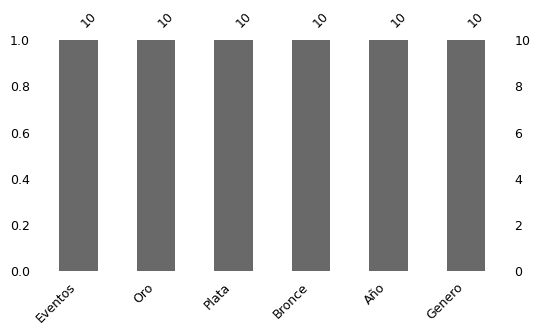

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


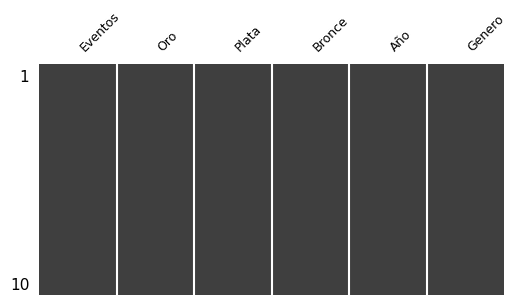

----------------------------------------------------------------------------------------------------


In [66]:
for k, v in dict_urls.items():
    print(f'################################ {k} ################################')
    exploracion_inicial(v)

## Paso 4. Crear un único dataframe con los datos de 2019, 2020, 2021, 2022, 2023 y 2024

In [67]:
# Verificar nulos en cada df antes de concatenar
print("Verificando nulos:")
for k, v in dict_urls.items():
    nulos = v.isnull().sum().sum()
    print(f"{k}: {nulos} nulos")

Verificando nulos:
2019_masculino: 0 nulos
2019_femenino: 0 nulos
2021_masculino: 0 nulos
2021_femenino: 0 nulos
2022_masculino: 0 nulos
2022_femenino: 0 nulos
2023_masculino: 0 nulos
2023_femenino: 0 nulos
2024_masculino: 0 nulos
2024_femenino: 0 nulos


In [68]:
# Concatenar todos los DataFrames
df_web = pd.concat(dict_urls.values(), ignore_index=True)
print(f"Shape total: {df_web.shape}")

Shape total: (100, 6)


In [69]:
# Verificar años
df_web['Año'].value_counts().sort_index()

Año
2019    20
2021    20
2022    20
2023    20
2024    20
Name: count, dtype: int64

In [70]:
df_web.head()

,Eventos,Oro,Plata,Bronce,Año,Genero
0,55 kg (06.04),Mirco Scarantino Italia 116 + 145 = 261[n 1]​,Anguel Rusev Bulgaria 110 + 146 = 256[n 1]​,Muammer Şahin Turquía 112 + 135 = 247[n 1]​,2019,Masculino
1,61 kg (07.04),Henadz Laptseu Bielorrusia 133 + 153 = 286,Bünyamin Sezer Turquía 132 + 151 = 283,Ferdi Hardal Turquía 127 + 155 = 282,2019,Masculino
2,67 kg (08.04),Bernardin Matam Francia 137 + 175 = 312,Simon Brandhuber Alemania 146 + 165 = 311,Goga Chjeidze Georgia 139 + 169 = 308,2019,Masculino
3,73 kg (09.04),Bozhidar Andreev Bulgaria 153 + 192 = 345,Briken Calja Albania 156 + 183 = 339,Vadzim Lijarad Bielorrusia 153 + 182 = 335,2019,Masculino
4,81 kg (10.04),Antonino Pizzolato Italia 155 + 201 = 356,Piotr Asayonak Bielorrusia 159 + 196 = 355,Ritvars Suharevs Letonia 162 + 192 = 354,2019,Masculino


## Paso 5. Transformar los datos

Transforma el DataFrame para tener las siguientes columnas: Eventos, Año, Genero, Medalla (que indica si es Oro, Plata o Bronce) y Atleta (que contiene la información del atleta correspondiente)

Formato inicial:

| Eventos | Oro | Plata | Bronce | Año | Género |
|---------|-----|-------|--------|-----|--------|

**¡Importante!**
El dataframe final debe tener este formato:

| Eventos | Año | Genero | Medalla | Atleta |
|---------|-----|-------|--------|-----|

### 5.1 Transformar con melt

In [71]:
df_web = df_web.melt(
    id_vars=['Eventos', 'Año', 'Genero'],
    value_vars=['Oro', 'Plata', 'Bronce'],
    var_name='Medalla',
    value_name='Atleta'
)
df_web = df_web.reset_index(drop=True)
print(f"Shape después de melt: {df_web.shape}")
df_web.head()

Shape después de melt: (300, 5)


,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261[n 1]​
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356


### 5.2 Detectar inconsistencias de los datos

In [72]:
# Detectar corchetes
print("Corchetes por columna:")
for col in df_web.columns:
    if df_web[col].dtype == 'object':
        n = df_web[col].str.contains('\[', na=False).sum()
        if n > 0:
            print(f"{col}: {n} filas")

Corchetes por columna:
Eventos: 3 filas
Atleta: 35 filas


In [73]:
# Detectar espacios dobles
print("Espacios dobles por columna:")
for col in df_web.columns:
    if df_web[col].dtype == 'object':
        n = df_web[col].str.contains('  ', na=False).sum()
        if n > 0:
            print(f"{col}: {n} filas")

Espacios dobles por columna:
Atleta: 300 filas


In [74]:
# Detectar caracteres invisibles (\u200b)
print("Caracteres invisibles (u200b) por columna:")
for col in df_web.columns:
    if df_web[col].dtype == 'object':
        n = df_web[col].str.contains('\u200b', na=False).sum()
        if n > 0:
            print(f"{col}: {n} filas")

Caracteres invisibles (u200b) por columna:
Eventos: 3 filas
Atleta: 35 filas


### 5.3 Limpiar datos

In [75]:
# Aplicar limpieza a todas las columnas de texto
# Reutilizamos las funciones de la Fase 1: limpiar_corchetes, limpiar_espacios, limpiar_invisibles
for col in df_web.columns:
    if df_web[col].dtype == 'object':
        df_web[col] = df_web[col].apply(limpiar_invisibles)
        df_web[col] = df_web[col].apply(limpiar_corchetes)
        df_web[col] = df_web[col].apply(limpiar_espacios)

print("Limpieza completada")

Limpieza completada


In [76]:
# Verificar
print("Verificación:")
for col in df_web.columns:
    if df_web[col].dtype == 'object':
        c = df_web[col].str.contains('\[', na=False).sum()
        e = df_web[col].str.contains('  ', na=False).sum()
        i = df_web[col].str.contains('\u200b', na=False).sum()
        print(f"{col}: corchetes={c}, espacios={e}, invisibles={i}")

Verificación:
Eventos: corchetes=0, espacios=0, invisibles=0
Genero: corchetes=0, espacios=0, invisibles=0
Medalla: corchetes=0, espacios=0, invisibles=0
Atleta: corchetes=0, espacios=0, invisibles=0


In [77]:
df_web.head()

,Eventos,Año,Genero,Medalla,Atleta
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356


## Paso 6. Creación de columnas


- Fecha
- Nombre
- Apellido
- País
- Resultados
- Arrancada
- Dos tiempos
- Total

In [78]:
# Normalizo 'Reino Unido' a 'UK' antes de extraer datos de nuevo
df_web['Atleta'] = df_web['Atleta'].str.replace('Reino Unido', 'UK')

In [79]:
# Reutilizamos las funciones de la Fase 1
# extraer_fecha, extraer_categoria, extraer_texto_atleta/extraer_numeros_atleta

df_web['Fecha'] = df_web['Eventos'].apply(extraer_fecha) + '.' + df_web['Año'].astype(str)
df_web['Categoría'] = df_web['Eventos'].apply(extraer_categoria)
df_web[['Arrancada', 'Dos tiempos', 'Total']] = df_web['Atleta'].apply(extraer_numeros_atleta)
df_web[['Nombre', 'Apellido', 'País']] = df_web['Atleta'].apply(extraer_texto_atleta)

df_web.head()

,Eventos,Año,Genero,Medalla,Atleta,Fecha,Categoría,Arrancada,Dos tiempos,Total,Nombre,Apellido,País
0,55 kg (06.04),2019,Masculino,Oro,Mirco Scarantino Italia 116 + 145 = 261,06.04.2019,55,116,145,261,Mirco,Scarantino,Italia
1,61 kg (07.04),2019,Masculino,Oro,Henadz Laptseu Bielorrusia 133 + 153 = 286,07.04.2019,61,133,153,286,Henadz,Laptseu,Bielorrusia
2,67 kg (08.04),2019,Masculino,Oro,Bernardin Matam Francia 137 + 175 = 312,08.04.2019,67,137,175,312,Bernardin,Matam,Francia
3,73 kg (09.04),2019,Masculino,Oro,Bozhidar Andreev Bulgaria 153 + 192 = 345,09.04.2019,73,153,192,345,Bozhidar,Andreev,Bulgaria
4,81 kg (10.04),2019,Masculino,Oro,Antonino Pizzolato Italia 155 + 201 = 356,10.04.2019,81,155,201,356,Antonino,Pizzolato,Italia


In [80]:
# Ver países únicos
print(df_web['País'].unique())

['Italia' 'Bielorrusia' 'Francia' 'Bulgaria' 'Armenia' 'Ucrania' 'Georgia'
 'Turquía' 'Rumania' 'Polonia' 'Letonia' 'Rusia' 'Alemania' 'Azerbaiyán'
 'UK' 'Albania' 'Suecia' 'Noruega' 'AIN' 'España' 'Bélgica' 'Moldavia'
 'Israel' 'Austria' 'Serbia' 'Irlanda' 'Finlandia']


In [81]:
# Renombro UK a Reino Unido para mejor lectura de los resultados
df_web['País'] = df_web['País'].replace({'UK': 'Reino Unido'})

In [82]:
# Frecuencia de países
print(df_web['País'].value_counts())

País
Armenia        44
Bulgaria       28
Turquía        28
Ucrania        27
Georgia        24
Rusia          20
Italia         19
Rumania        16
Reino Unido    11
España         10
Francia         9
Bielorrusia     9
Letonia         7
Moldavia        7
Alemania        7
Polonia         6
Noruega         5
AIN             4
Albania         4
Bélgica         4
Azerbaiyán      3
Suecia          2
Austria         2
Israel          1
Serbia          1
Irlanda         1
Finlandia       1
Name: count, dtype: int64


## Paso 7. Filtrado de columnas y ordenación

**¡Importante!**
El dataframe final debe contener exclusivamente las siguientes columnas:

| Género    | Categoría | Fecha | Medalla | Nombre | Apellido | País | Arrancada | Dos tiempos | Total |
|-----------|-----------|-------|---------|--------|----------|------|-----------|-------------|-------|

In [83]:
# Reutilizamos la lista de columnas de la Fase 1
df_web = df_web[columnas_finales]
df_web.head()

,Genero,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Masculino,55,06.04.2019,Oro,Mirco,Scarantino,Italia,116,145,261
1,Masculino,61,07.04.2019,Oro,Henadz,Laptseu,Bielorrusia,133,153,286
2,Masculino,67,08.04.2019,Oro,Bernardin,Matam,Francia,137,175,312
3,Masculino,73,09.04.2019,Oro,Bozhidar,Andreev,Bulgaria,153,192,345
4,Masculino,81,10.04.2019,Oro,Antonino,Pizzolato,Italia,155,201,356


## Paso 8. Tipo de datos

**¡Importante!**
Los tipos de las columnas deben ser los siguientes:

- **Género**: `object`
- **Categoría**: `category`
- **Fecha**: `datetime64[ns]`
- **Medalla**: `category`
- **Nombre**: `object`
- **Apellido**: `object`
- **País**: `object`
- **Arrancada**: `int64`
- **Dos tiempos**: `int64`
- **Total**: `int64`

In [84]:
# Tipos datos antes 
df_web.dtypes

Genero         object
Categoría      object
Fecha          object
Medalla        object
Nombre         object
Apellido       object
País           object
Arrancada       int64
Dos tiempos     int64
Total           int64
dtype: object

In [85]:
# Obtener categorías únicas de este dataset
categorias_web = df_web['Categoría'].unique().tolist()
categorias_web_ordenadas = ordenar_categorias(categorias_web)
print(categorias_web_ordenadas)

['45', '49', '55', '59', '61', '64', '67', '71', '73', '76', '81', '87', '+87', '89', '96', '102', '109', '+109']


In [86]:
# Convertir tipos
df_web['Fecha'] = pd.to_datetime(df_web['Fecha'], format='%d.%m.%Y')
df_web['Categoría'] = pd.Categorical(df_web['Categoría'], categories=categorias_web_ordenadas, ordered=True)
df_web['Medalla'] = pd.Categorical(df_web['Medalla'], categories=['Oro', 'Plata', 'Bronce'], ordered=True)
df_web['Arrancada'] = df_web['Arrancada'].astype('int64')
df_web['Dos tiempos'] = df_web['Dos tiempos'].astype('int64')
df_web['Total'] = df_web['Total'].astype('int64')

print(df_web.dtypes)

Genero                 object
Categoría            category
Fecha          datetime64[ns]
Medalla              category
Nombre                 object
Apellido               object
País                   object
Arrancada               int64
Dos tiempos             int64
Total                   int64
dtype: object


## Paso 9. Ordenar
**¡Importante!**
El conjunto de datos debe estar ordenado por las siguientes columnas:
['Genero', 'Categoria', 'Medalla']. La siguiente imagen es un ejemplo:

| Genero   | Categoria | Fecha      | Medalla | Nombre    | Apellido | País      | Arrancada | Dos tiempos | Total |
|----------|-----------|------------|---------|-----------|----------|-----------|-----------|-------------|-------|
| Femenino | 45        | 2020-04-03 | Oro     | Nadezhda  | Nguen    | Bulgaria  | 72        | 83          | 155   |
| Femenino | 45        | 2020-04-03 | Plata   | Ivana     | Petrova  | Bulgaria  | 67        | 85          | 152   |
| Femenino | 45        | 2020-04-03 | Bronce  | Melisa    | Güneş    | Turquía   | 68        | 83          | 151   |
| Femenino | 49        | 2020-04-03 | Oro     | Monica    | Csengeri | Rumania   | 86        | 103         | 189   |
| Femenino | 49        | 2020-04-03 | Plata   | Kristina  | Sobol    | Rusia     | 85        | 96          | 181   |


In [87]:
df_web = df_web.sort_values(by=['Genero', 'Categoría', 'Medalla'])
df_web = df_web.reset_index(drop=True)
print(df_web.shape)
df_web.head(15)

(300, 10)


,Genero,Categoría,Fecha,Medalla,Nombre,Apellido,País,Arrancada,Dos tiempos,Total
0,Femenino,45,2019-04-06,Oro,Şaziye,Erdoğan,Turquía,75,88,163
1,Femenino,45,2021-04-03,Oro,Nadezhda,Nguen,Bulgaria,72,83,155
2,Femenino,45,2022-05-28,Oro,Şaziye,Erdoğan,Turquía,73,90,163
3,Femenino,45,2023-04-15,Oro,Cansu,Bektaş,Turquía,72,90,162
4,Femenino,45,2024-02-12,Oro,Cansu,Bektaş,Turquía,75,88,163
5,Femenino,45,2019-04-06,Plata,Ivana,Petrova,Bulgaria,69,89,158
6,Femenino,45,2021-04-03,Plata,Ivana,Petrova,Bulgaria,67,85,152
7,Femenino,45,2022-05-28,Plata,Cansu,Bektaş,Turquía,68,85,153
8,Femenino,45,2023-04-15,Plata,Adriana,Pană,Rumania,70,83,153
9,Femenino,45,2024-02-12,Plata,Gamze,Altun,Turquía,65,92,157


## Paso 10. EDA
Realiza un análisis exploratorio de los datos que te permita ganar conocimiento sobre el conjunto de datos antes de resolver a las preguntas

In [88]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Genero       300 non-null    object        
 1   Categoría    300 non-null    category      
 2   Fecha        300 non-null    datetime64[ns]
 3   Medalla      300 non-null    category      
 4   Nombre       300 non-null    object        
 5   Apellido     300 non-null    object        
 6   País         300 non-null    object        
 7   Arrancada    300 non-null    int64         
 8   Dos tiempos  300 non-null    int64         
 9   Total        300 non-null    int64         
dtypes: category(2), datetime64[ns](1), int64(3), object(4)
memory usage: 20.3+ KB


In [89]:
df_web.describe()

,Fecha,Arrancada,Dos tiempos,Total
count,300,300.000000,300.000000,300.000000
mean,2022-01-27 18:14:24,128.253333,155.543333,284.136667
min,2019-04-06 00:00:00,65.000000,11.000000,150.000000
25%,2021-04-04 18:00:00,99.000000,120.000000,221.000000
50%,2022-06-01 00:00:00,114.000000,141.000000,254.500000
75%,2023-04-21 06:00:00,162.250000,196.000000,360.750000
max,2024-02-20 00:00:00,222.000000,263.000000,485.000000
std,NaN,37.785557,45.084255,81.919640


In [90]:
df_web.describe(include='object')

,Genero,Nombre,Apellido,País
count,300,300,300,300
unique,2,151,170,27
top,Femenino,Anastasiya,Rusev,Armenia
freq,150,11,5,44


### 10.1 Univariable

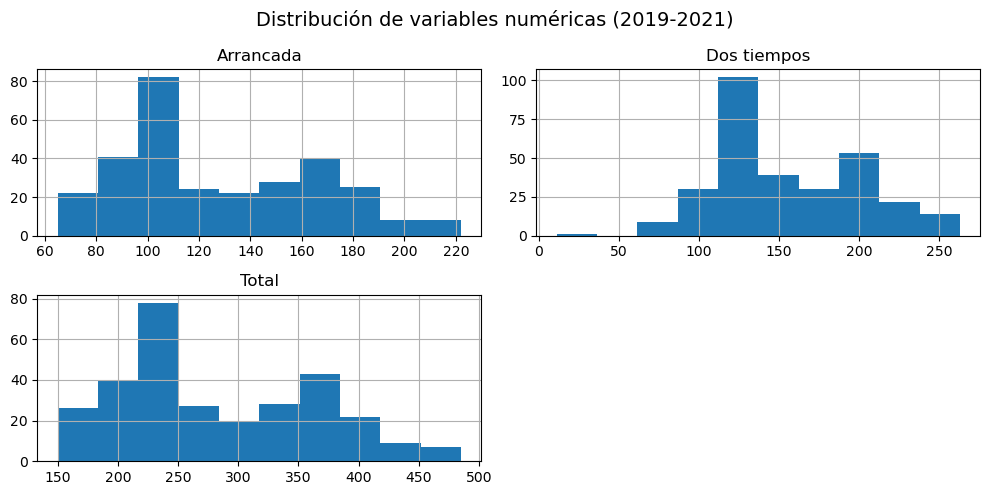

In [91]:
lista_columnas_numericas_w = df_web.select_dtypes(include = 'number').columns.to_list()

df_web[lista_columnas_numericas].hist(figsize=(10, 5))
plt.suptitle('Distribución de variables numéricas (2019-2021)', fontsize=14)
plt.tight_layout()
plt.show()

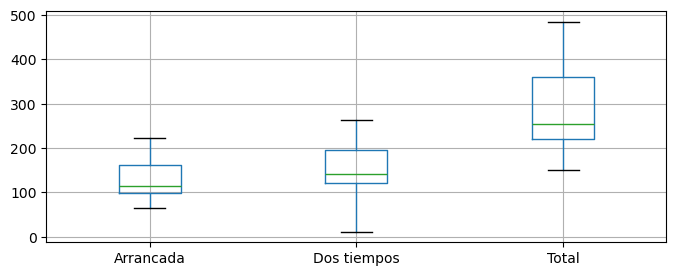

In [92]:

df_web[lista_columnas_numericas_w].boxplot(figsize = (8, 3))
plt.show()

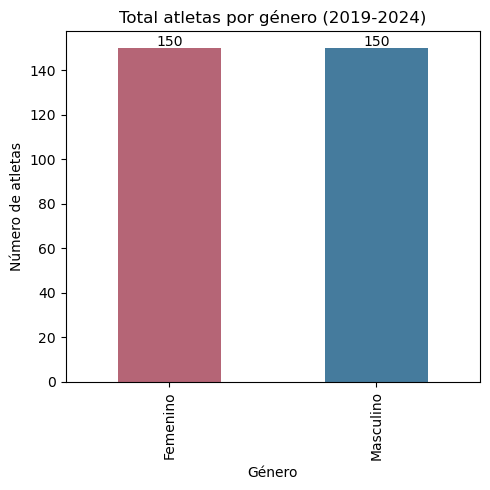

In [109]:
fig, ax = plt.subplots(figsize=(5, 5))
conteo_genero_w = df_web['Genero'].value_counts(dropna=False)
conteo_genero_w.plot(kind='bar', ax=ax, color= ['#B56576', '#457B9D'])

ax.set_title('Total atletas por género (2019-2024)')
ax.set_xlabel('Género')
ax.set_ylabel('Número de atletas')

for i, v in enumerate(conteo_genero_w.values):
    ax.text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

In [94]:
top_genero_w = (df_web.sort_values(['Genero', 'Total'], ascending=[True, False]).groupby('Genero').head(15)
[['Nombre', 'Apellido', 'País', 'Genero', 'Categoría', 'Total', 'Medalla']])

top_genero_w

,Nombre,Apellido,País,Genero,Categoría,Total,Medalla
135,Tatiana,Kashirina,Rusia,Femenino,+87,331,Oro
124,Solfrid,Koanda,Noruega,Femenino,87,280,Oro
136,Emily,Campbell,Reino Unido,Femenino,+87,276,Oro
123,Solfrid,Koanda,Noruega,Femenino,87,272,Oro
137,Emily,Campbell,Reino Unido,Femenino,+87,271,Oro
140,Anastasiya,Lysenko,Ucrania,Femenino,+87,268,Plata
139,Emily,Campbell,Reino Unido,Femenino,+87,263,Oro
145,Emily,Campbell,Reino Unido,Femenino,+87,260,Bronce
108,Iryna,Deja,Ucrania,Femenino,81,258,Oro
144,Anastasiya,Hotfrid,Georgia,Femenino,+87,257,Plata


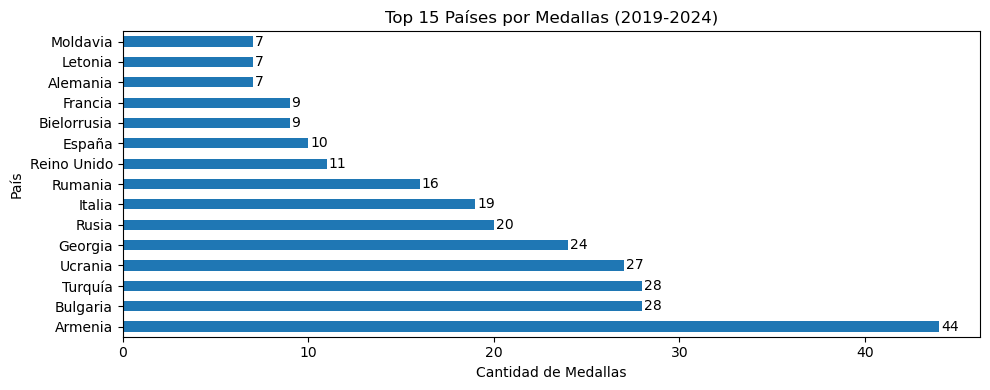

In [95]:
# Gráfico de medallas por país (Top 15)
ax = df_web['País'].value_counts().head(15).plot(kind='barh', figsize=(10,4 ))
plt.title('Top 15 Países por Medallas (2019-2024)')
plt.xlabel('Cantidad de Medallas')
plt.ylabel('País')

# Añadir etiquetas
for i, v in enumerate(df_web['País'].value_counts().head(15).values):
    ax.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.show()

### 10.2 Bivariable

### País vs medallas oro/plata/bronce web

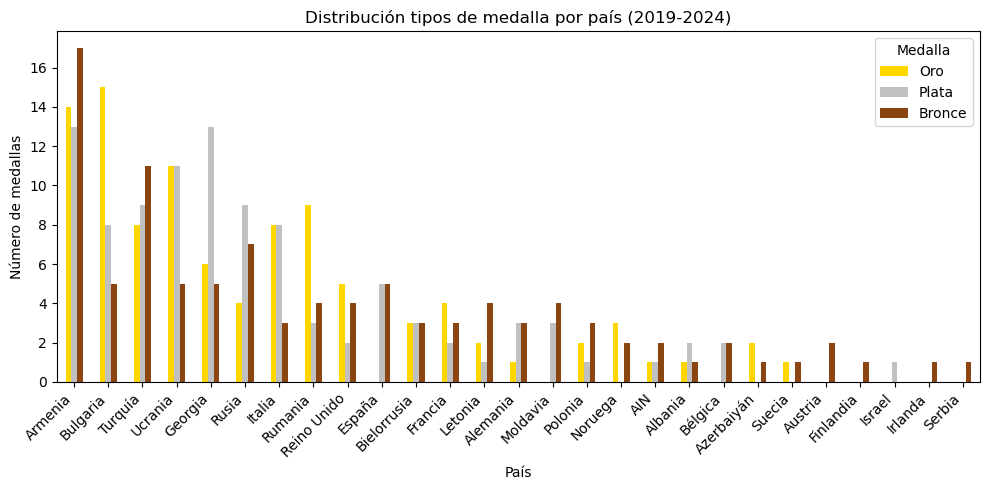

In [96]:
medallas_v_w = pd.crosstab(df_web['País'], df_web['Medalla'])
medallas_v_w_temp = medallas_v_w.copy()
medallas_v_w_temp['Total'] = medallas_v_w_temp.sum(axis=1)
medallas_v_w_temp = medallas_v_w_temp.sort_values('Total', ascending=False)

colores = ['gold', 'silver', 'saddlebrown']

medallas_v_w_temp[['Oro', 'Plata', 'Bronce']].plot(kind='bar', figsize=(10, 5), color=colores)

plt.title('Distribución tipos de medalla por país (2019-2024)')
plt.xlabel('País')
plt.ylabel('Número de medallas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### País vs género web

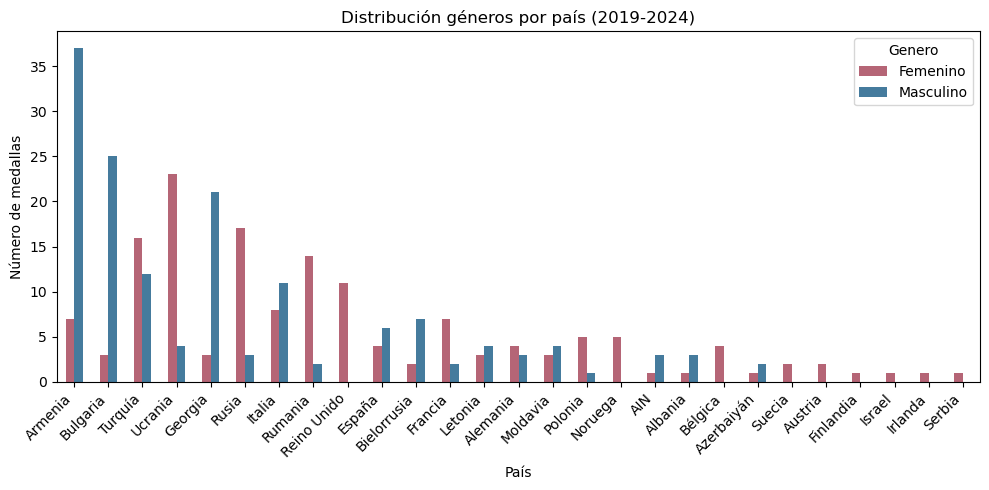

In [97]:
genero_v_w = pd.crosstab(df_web['País'], df_web['Genero'])
genero_v_w_temp = genero_v_w.copy()
genero_v_w_temp['Total'] = genero_v_w_temp.sum(axis=1)
genero_v_w_temp = genero_v_w_temp.sort_values('Total', ascending=False)

colores = ['#B56576', '#457B9D']
genero_v_w_temp[['Femenino', 'Masculino']].plot(kind='bar', figsize=(10, 5), color=colores)

plt.title('Distribución géneros por país (2019-2024)')
plt.xlabel('País')
plt.ylabel('Número de medallas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Preguntas obligatorias a resolver**

### ¿Cuántas medallas de cada tipo (oro, plata y bronce) ha ganado cada país en la competición? (Sin considerar el género)

In [98]:
medallas_web = pd.crosstab(df_web['País'], df_web['Medalla'])
medallas_web['Total'] = medallas_web.sum(axis=1)
medallas_web_o = medallas_web.sort_values('Total', ascending=False)
medallas_web_o

Medalla,Oro,Plata,Bronce,Total
País,,,,
Armenia,14,13,17,44
Bulgaria,15,8,5,28
Turquía,8,9,11,28
Ucrania,11,11,5,27
Georgia,6,13,5,24
Rusia,4,9,7,20
Italia,8,8,3,19
Rumania,9,3,4,16
Reino Unido,5,2,4,11


### ¿Qué país ha logrado la mayor equidad en términos de éxito entre sus atletas femeninos y masculinos?

In [99]:
equidad_w = pd.crosstab(df_web['País'], df_web['Genero'])
condicion_w = (equidad_w['Femenino'] > 0) & (equidad_w['Masculino'] > 0)
equidad_w_f = equidad_w[condicion_w].copy()

equidad_w_f['Diff'] = abs(equidad_w_f['Femenino'] - equidad_w_f['Masculino'])
equidad_w_o = equidad_w_f.sort_values('Diff')

min_diff_w = equidad_w_o['Diff'].min()
paises_mas_equidad_w = equidad_w_o[equidad_w_o['Diff'] == min_diff_w]

print(f'Los países con mayor equidad son: {paises_mas_equidad_w.index.tolist()}')
equidad_w_o

Los países con mayor equidad son: ['Alemania', 'Azerbaiyán', 'Moldavia', 'Letonia']


Genero,Femenino,Masculino,Diff
País,,,
Alemania,4,3,1
Azerbaiyán,1,2,1
Moldavia,3,4,1
Letonia,3,4,1
España,4,6,2
AIN,1,3,2
Albania,1,3,2
Italia,8,11,3
Polonia,5,1,4


### ¿En qué país es menor la diferencia entre el promedio de puntos totales conseguidos por atletas femeninos y masculinos?

In [100]:
prom_w = pd.pivot_table(df_web,values='Total',index='País',columns='Genero',aggfunc='mean')
prom_w_f = prom_w.dropna()

prom_w_f['Diff'] = abs(prom_w_f['Femenino'] - prom_w_f['Masculino'])
prom_w_o = prom_w_f.sort_values('Diff').round(0).astype(int) # Tabla con resultado todos los países

prom_p_w = prom_w_o.index[0] # País con menor diferencia promedio
print(f"País con menor diferencia: {prom_p_w}")
prom_w_o

País con menor diferencia: Rumania


Genero,Femenino,Masculino,Diff
País,,,
Rumania,210,246,37
Ucrania,226,322,96
Alemania,223,325,102
Turquía,199,308,109
Francia,225,341,116
Polonia,207,324,117
Georgia,248,365,117
Letonia,222,342,120
Moldavia,238,364,126


# Insights

**1. Insight:**

Dominancia de Rusia en los años y su desaparición:
* Fase 1 (2019-2021): Rusia era el país líder con 20 medallas, dominando la competición frente a otros países.
* Fase 2 (2019-2024): Rusia desaparece a partir de 2022 debido a sanciones por dopaje de Estado y exclusión tras la invasión de Ucrania (2022).

Los atletas rusos que compiteron como AIN( Atletas Individuales Neutrales) en 2023-2024 solo consiguen 4 medallas.

In [101]:
medallas_o.head(3)

Medalla,Oro,Plata,Bronce,Total
País,,,,
Rusia,4,9,7,20
Armenia,4,3,7,14
Bulgaria,4,5,1,10


In [102]:
medallas_web_o.head(3)

Medalla,Oro,Plata,Bronce,Total
País,,,,
Armenia,14,13,17,44
Bulgaria,15,8,5,28
Turquía,8,9,11,28


In [103]:
df_temp = df_web.copy()
df_temp['Año'] = df_temp['Fecha'].dt.year

print("Medallas de Rusia por año:")
print(df_temp[df_temp['País'] == 'Rusia'].groupby('Año').size())

print("\nMedallas de AIN por año:")
print(df_temp[df_temp['País'] == 'AIN'].groupby('Año').size())

Medallas de Rusia por año:
Año
2019    11
2021     9
dtype: int64

Medallas de AIN por año:
Año
2024    4
dtype: int64


**2. Insight:**

 Nuevos países llenan el vacío de Rusia:
 * Fase 1: Top 3 -> Rusia, Armenia y Bulgaria.
 * Fase 2: Top 3 -> Armenia, Bulgaria y Turquía. 

Bulgaria y Armenia han consolidado su posición, pasando a ser los países referentes. 

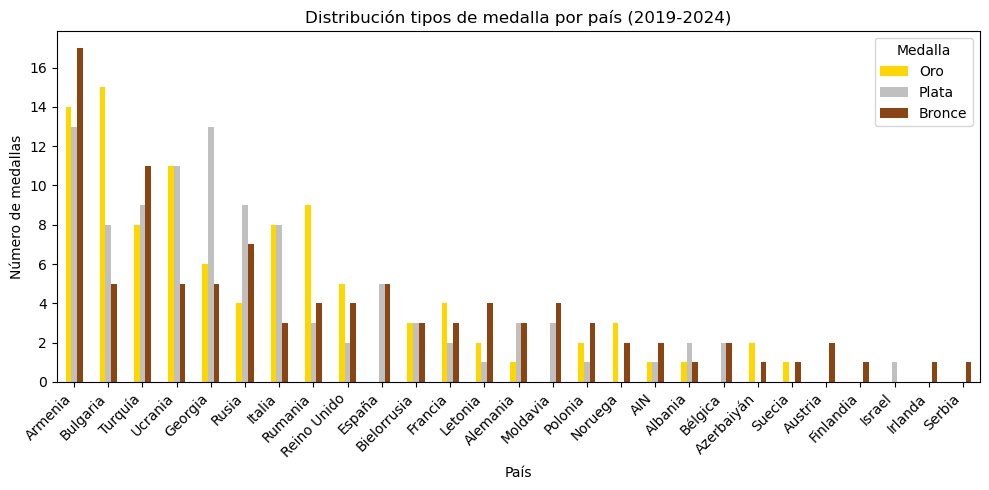

**3. Insight:**

En ambas fases, los países con representación de ambos géneros y menor número total de medallas mostraron mayor equidad: Alemania, Azerbaiyán y Moldavia con diferencia = 0/1.   
Los países con representación de ambos géneros con mayor número total de medallas tendieron a tener menor equidad, generalmente hacia el género masculino.

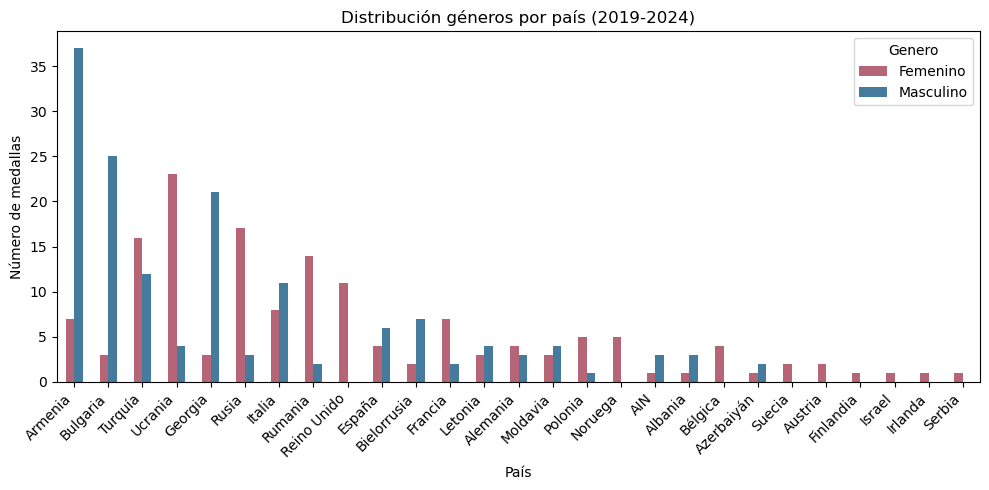

**4. Insight:**

A pesar de que Georgia no está en el top 3 de países con más medallas totales en ambas fases analizadas, el atleta con el resultado total más alto es el georgiano Lasha Talajadze,   
con 485 kg total.   
En la categoría femenina, la rusa Tatiana Kashirina fue la que obtuvo el resultado total más alto con 331kg total, muy por encima del top 2 (280 kg) y top 3 (276 kg),   
correspondientes además a países que tampoco están en el top 3 de países con más medallas totales.

In [104]:
top_genero_w.groupby('Genero').head(3)

,Nombre,Apellido,País,Genero,Categoría,Total,Medalla
135,Tatiana,Kashirina,Rusia,Femenino,+87,331,Oro
124,Solfrid,Koanda,Noruega,Femenino,87,280,Oro
136,Emily,Campbell,Reino Unido,Femenino,+87,276,Oro
286,Lasha,Talajadze,Georgia,Masculino,+109,485,Oro
285,Lasha,Talajadze,Georgia,Masculino,+109,478,Oro
288,Lasha,Talajadze,Georgia,Masculino,+109,474,Oro


**5. Insight:**   

El gráfico inferior muestra que la media de puntos totales se manteniene estable en ambos géneros a lo largo de los 5 años de competición analizados:
- Categoría masculina: Las medias oscilan entre 348-356kg, con una ligera tendencia descendente desde 2021 (356 kg) hasta 2024 (348 kg). 
- Categoría femenina: Muy estable entre 214-219 kg, prácticamente sin variación significativa, posible establización en los años analizados

La expulsión de Rusia a partir de 2022, que era potencia con atletas de ambos géneros en el top 15 de puntos totales más altos, podría explicar estas pequeñas diferencias.

Cabe recalcar que de 2019-2021, las competiciones tuvieron representación de 21 países y a partir de 2022, esta cifra aumentó a 27, incorporando nuevos países del continente Europeo como Finlandia, Irlanda, Noruega y Serbia. 

Estos resultados hacen valorar que, aunque el rendimiento deportivo de élite se mantiene estable, el aumento de participación y diversificación de países a lo largo de los años muestra un posible crecimiento del interés por la halterofilia europea.

In [105]:
paises_2019_2021 = set(df['País'].unique())
paises_2019_2024 = set(df_web['País'].unique())

paises_nuevos = paises_2019_2024 - paises_2019_2021
paises_nuevos


{'AIN', 'Finlandia', 'Irlanda', 'Israel', 'Noruega', 'Serbia'}

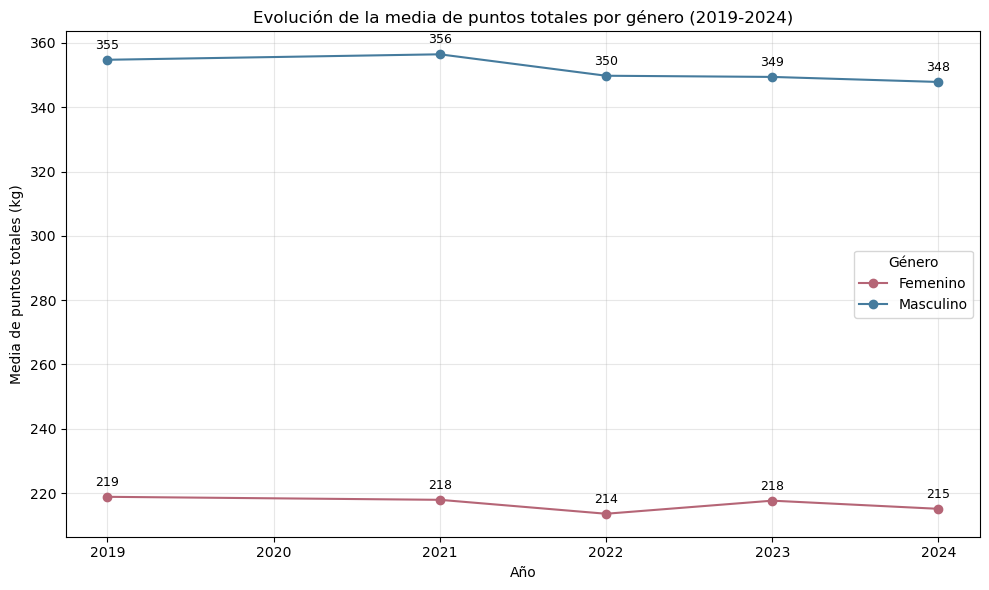

In [106]:
# Tendencia de media de Total por Género y Año
tendencia = df_web.groupby([df_web['Fecha'].dt.year, 'Genero'])['Total'].mean().unstack()
tendencia.columns.name = None

ax = tendencia.plot(kind='line', marker='o', figsize=(10, 6), color=['#B56576', '#457B9D'])
plt.title('Evolución de la media de puntos totales por género (2019-2024)')
plt.xlabel('Año')
plt.ylabel('Media de puntos totales (kg)')
plt.legend(title='Género')
plt.grid(True, alpha=0.3)

# Añadir etiquetas en cada punto
for col in tendencia.columns:
    for año, valor in tendencia[col].items():
        ax.annotate(f'{valor:.0f}', (año, valor), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**6. Insight:**   

Tras todos los insights analizados, para finalizar se muestra además, un mapa de calor con patrones clave para poder responder el análisis de mercado de Lift & Head.

- Rusia (2019-2021) era la potencia dominante con 11 y 9 medallas respectivamente. Su expulsión desde 2022 dejó dejó un vacío en el medallero.
- Armenia es el país más consistente en crecimiento (6-8-7-13-10). Ha llenado en parte, el vacío que dejó Rusia, consolidándose como la nueva potencia.
- Bulgaria, Turquía, Ucrania y Georgia mantuvieron cifras consistentes, indicando una cultura de halterofilia establecida y posiblemente de infraestructuras deportivas.

- Italia aunque no forma parte del top 5 de países, muestra un patrón estable con tendencia al alza desde 2023 pudiendo ser un país con potencial de crecimiento. Se aprecia una tendencia similar con Rumania y una tendencia algo más estable con Reino Unido.
- España en cambio, tiene un patrón algo más errático con un crecimiento en las medallas a partir de 2022, pero desaceleracióon en los años posteriores. Podría ser un país con potencial de crecimiento pero harían falta más datos para corroborarlo. 

En resumen, la popularidad de la halterofilia está aumentando en los últimos años, reflejándose en el crecimiento de la participación y diversidad de los países, así como el incremento del nivel deportivo de países emergentes.

Sería recomendable hacer futuros análisis orientados no solo al estudio de las tendencias de la halterofilia de élite, sino de deportes emergentes relacionados como el Crossfit y su variantes a niveles amateur.

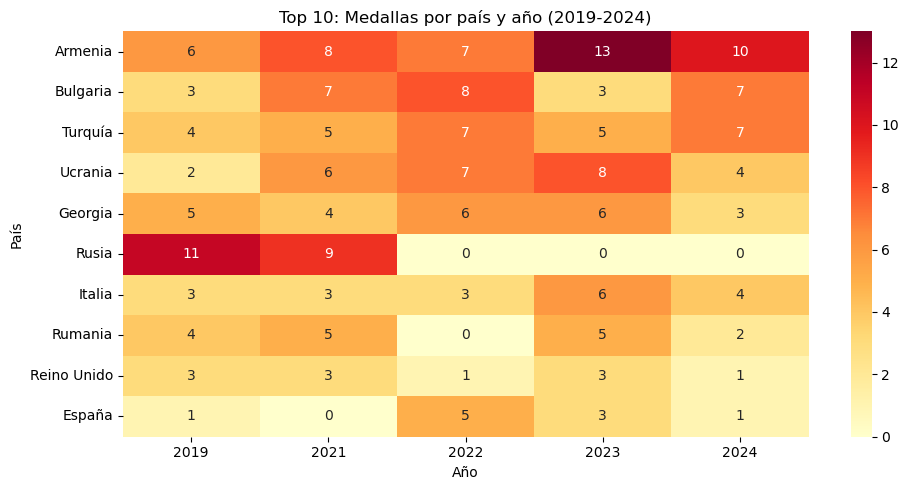

In [107]:
pivot = df_web.pivot_table(index='País', columns=df_web['Fecha'].dt.year, aggfunc='size', fill_value=0)

# Top 10 países
top_paises = df_web['País'].value_counts().head(10).index
pivot_top = pivot.loc[top_paises]

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_top, annot=True, cmap='YlOrRd', fmt='d')
plt.title('Top 10: Medallas por país y año (2019-2024)')
plt.xlabel('Año')
plt.ylabel('País')
plt.tight_layout()
plt.show()